# NSSC 2026 - Unsupervised Anomaly Detection in Mars HiRISE Imagery
**Pipeline:** custom Convolutional / Variational Autoencoder (no pretrained weights) -> 1-D latent vectors -> Isolation Forest novelty scores -> statistical threshold -> source-metadata analysis -> reconstruction-error heatmaps -> v1/v2/v3 engineering changelog -> interactive "find the most different images" tool.

| Section | Content | Marks |
|---|---|---|
| 0 | Setup, data loading, sanity pass | - |
| Phase 1 | 1.1 Architecture, 1.2 Loss, 1.3 Latent visualisation | 30 |
| Phase 2 | 2.1 Novelty scoring, 2.2 Statistical thresholding, 2.3 Location analysis, 2.4 Metadata fusion (optional) | 20 (+2) |
| Phase 3 | 3.1 Pixel-wise error heatmaps, 3.2 Geological report | 25 |
| Phase 4 | Architecture iteration and design journal (v1 -> v3) | 25 |
| Inference | Clean UI: drop any folder of images -> top-5 most different + 10 % near-miss tier | - |

**How to run:** put the Mars crops folder next to this notebook (or edit `IMAGES_DIR`), then *Run All*. Set `QUICK_TEST = True` first for a ~minutes smoke test.

In [1]:
import os


In [2]:
# Install anything missing (Colab already has torch / sklearn / matplotlib)
import importlib, subprocess, sys
for pip_name, module_name in [("umap-learn", "umap"), ("kneed", "kneed"), ("ipywidgets", "ipywidgets"),
                              ("tqdm", "tqdm"), ("joblib", "joblib"), ("scipy", "scipy")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
print("dependencies ready")

dependencies ready


## 0. Setup, Data Loading and Sanity Pass
All tunable settings live in one cell. **Only pretrained-free components are used**: every network layer is initialised from scratch.

In [3]:
import os, sys, json, math, random, time, warnings, io, base64, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import joblib
from IPython.display import display, HTML, Markdown
warnings.filterwarnings("ignore")

# ------------------------------- USER SETTINGS -------------------------------
QUICK_TEST = True     # True = tiny run to check everything works

IMAGES_DIR = Path(r"G:\My Drive\images")                    # folder holding sample_00001.jpg ... (auto-searched if wrong)
CROP_CSV   = Path("crop_metadata_index.csv")
SRC_CSV    = Path("source_image_metadata.csv")
OUT_DIR    = Path("artifacts");  OUT_DIR.mkdir(exist_ok=True)
CHANGELOG_DIR = Path("changelog"); CHANGELOG_DIR.mkdir(exist_ok=True)

SEED       = 42
IMG        = 227
EPOCHS     = 25            # epochs per version (v1, v2, v3)
BATCH      = 64
LR         = 1e-3
BASE_CH    = 32            # channel width of the first conv block
BETA_KL    = 1e-3          # KL weight for the VAE (v3)
KL_WARMUP  = 5             # epochs of linear KL warm-up
LAMBDA_MSE = 10.0          # loss = LAMBDA_MSE * MSE + (1 - SSIM)
LATENT_SWEEP    = [64, 128, 256, 512]
SWEEP_EPOCHS    = 6
SWEEP_N         = 4000     # training images used per sweep run
LATENT_DIM_OVERRIDE = None # e.g. 256 to skip the sweep decision
FINAL_VERSION   = "auto"   # "auto" = best proxy-AUROC among v1/v2/v3, or force "v1"/"v2"/"v3"
THRESHOLD_METHOD = "mad"   # "mad" (default) | "knee" | "kde" | "sigma"
MAD_K = 3.5                # modified z-score cut-off (Iglewicz & Hoaglin)
N_LIMIT = None             # use only N crops (debugging)

if QUICK_TEST:
    N_LIMIT, EPOCHS, BASE_CH, BATCH = 500, 2, 8, 32
    LATENT_SWEEP, SWEEP_EPOCHS, SWEEP_N, KL_WARMUP = [32, 64], 1, 300, 1
# -----------------------------------------------------------------------------

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| torch", torch.__version__, "| QUICK_TEST =", QUICK_TEST)

device: cuda | torch 2.7.1+cu118 | QUICK_TEST = True


In [4]:
# ---- 0.1 Load metadata and verify the join ----
df_crop = pd.read_csv(CROP_CSV)
df_src  = pd.read_csv(SRC_CSV)
print("crop index :", df_crop.shape, "| source metadata:", df_src.shape)
assert df_crop["filename"].is_unique, "duplicate filenames in crop index"
assert df_src["source_image_id"].is_unique, "duplicate source ids in metadata"
orphans = (~df_crop["source_image_id"].isin(df_src["source_image_id"])).sum()
print("crops whose source id is missing from metadata:", orphans)

# locate the image folder even if IMAGES_DIR is slightly wrong
first_name = df_crop["filename"].iloc[0]
if not (IMAGES_DIR / first_name).exists():
    hits = list(Path(".").rglob(first_name))
    if hits:
        IMAGES_DIR = hits[0].parent
        print("image folder auto-detected ->", IMAGES_DIR)
    else:
        raise FileNotFoundError(f"Could not find {first_name}. Set IMAGES_DIR to the folder with the crops.")

present = df_crop["filename"].apply(lambda f: (IMAGES_DIR / f).exists())
print(f"files found on disk: {present.sum()} / {len(df_crop)}")
df_crop = df_crop[present].reset_index(drop=True)
if N_LIMIT is not None and len(df_crop) > N_LIMIT:
    df_crop = df_crop.sample(N_LIMIT, random_state=SEED).reset_index(drop=True)
N = len(df_crop)
print("crops used:", N)

crop index : (10422, 2) | source metadata: (172, 6)
crops whose source id is missing from metadata: 0


files found on disk: 10422 / 10422
crops used: 500


In [5]:
# ---- 0.2 Load every crop as a uint8 grayscale tensor (227 x 227) ----
def load_gray_u8(path):
    with Image.open(path) as im:
        im = im.convert("L")
        if im.size != (IMG, IMG):
            im = im.resize((IMG, IMG), Image.BILINEAR)
        return np.asarray(im, dtype=np.uint8)

X_u8 = np.zeros((N, IMG, IMG), dtype=np.uint8)
for i in tqdm(range(N), desc="loading images"):
    X_u8[i] = load_gray_u8(IMAGES_DIR / df_crop.loc[i, "filename"])

X = torch.from_numpy(X_u8).unsqueeze(1).to(DEVICE)       # N x 1 x 227 x 227, uint8 (scaled to [0,1] per batch)
print("tensor:", tuple(X.shape), X.dtype, f"| {X.numel() / 1e6:.0f} MB")

loading images:   0%|          | 0/500 [00:00<?, ?it/s]

tensor: (500, 1, 227, 227) torch.uint8 | 26 MB


pixel min/max: 0 255 | global mean 118.5  std 44.9


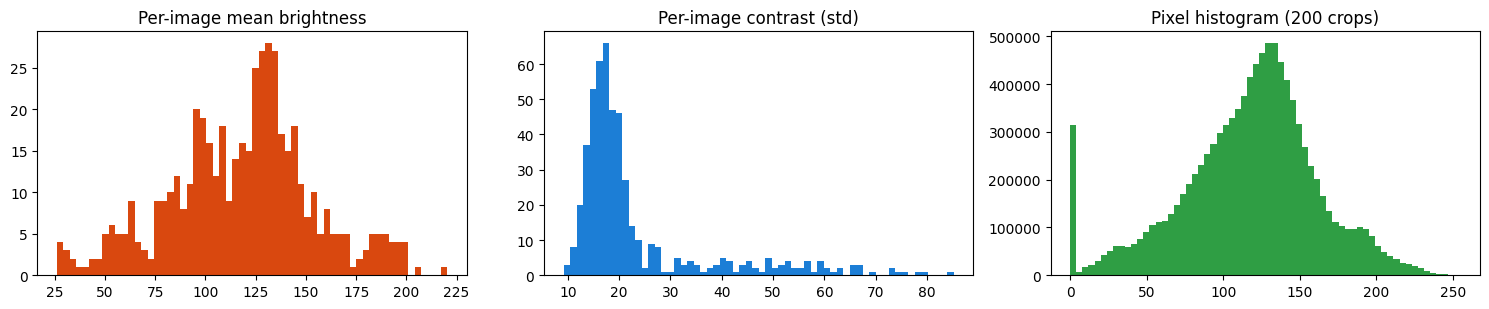

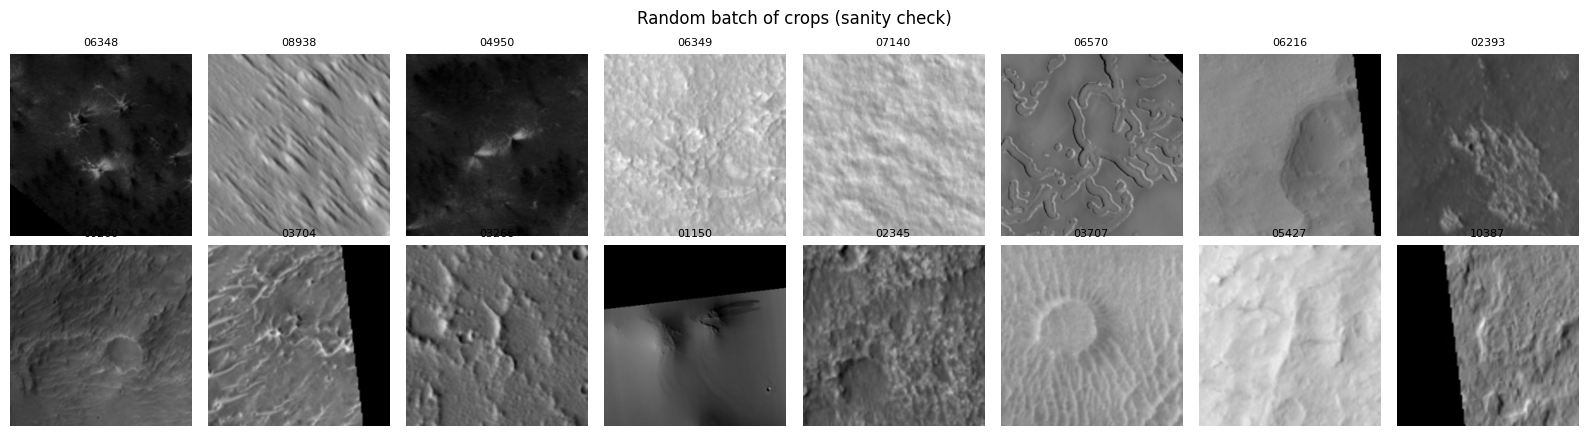

train: 450 | validation: 50


In [6]:
# ---- 0.3 Sanity pass: pixel range, brightness distribution, random batch ----
print("pixel min/max:", X_u8.min(), X_u8.max(), "| global mean %.1f  std %.1f" % (X_u8.mean(), X_u8.std()))
img_mean = X_u8.reshape(N, -1).mean(axis=1)
img_std  = X_u8.reshape(N, -1).std(axis=1)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].hist(img_mean, bins=60, color="#d9480f"); ax[0].set_title("Per-image mean brightness")
ax[1].hist(img_std, bins=60, color="#1c7ed6");  ax[1].set_title("Per-image contrast (std)")
ax[2].hist(X_u8[:200].ravel(), bins=64, color="#2f9e44"); ax[2].set_title("Pixel histogram (200 crops)")
plt.tight_layout(); plt.show()

rng_view = np.random.default_rng(SEED)
pick = rng_view.choice(N, size=min(16, N), replace=False)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))
for a, i in zip(axes.ravel(), pick):
    a.imshow(X_u8[i], cmap="gray", vmin=0, vmax=255); a.axis("off"); a.set_title(df_crop.loc[i, "filename"][-9:-4], fontsize=8)
plt.suptitle("Random batch of crops (sanity check)"); plt.tight_layout(); plt.show()

# ---- 80/10/10 style split: 90 % train, 10 % validation (used for model selection only) ----
perm = np.random.default_rng(SEED).permutation(N)
n_val = max(20, int(0.1 * N))
val_np, train_np = perm[:n_val], perm[n_val:]
train_idx = torch.from_numpy(train_np).long().to(DEVICE)
val_idx   = torch.from_numpy(val_np).long().to(DEVICE)
print("train:", len(train_np), "| validation:", len(val_np))

# Phase 1 - Deep Latent Compression (Autoencoders)
## 1.1 Architecture Design
**Design reasoning (all layers trained from scratch):**
- **Encoder:** five stride-2 convolutions (`k=3, p=1`) shrink 227 -> 114 -> 57 -> 29 -> 15 -> 8 while channels grow 1 -> 32 -> 64 -> 128 -> 256 -> 256. Strided convs (not max-pool) let the network learn its own down-sampling, and BatchNorm + LeakyReLU keep gradients healthy.
- **Bottleneck:** a linear layer maps the 256x8x8 feature map to a **fixed-length 1-D latent vector** (`latent_dim`). This is the vector passed to the Isolation Forest.
- **Decoder:** mirrors the encoder with five transposed convolutions (8 -> 256), then a bilinear resize to the odd size 227 and a final conv + sigmoid (outputs in [0,1]).
- **Variational option:** with `variational=True` the bottleneck outputs `(mu, logvar)`; training samples `z = mu + eps*sigma` and the **mean `mu` is the latent** used downstream (used in v3).

In [7]:
%%writefile model_def.py
import torch, torch.nn as nn, torch.nn.functional as F

class MemoryModule(nn.Module):
    def __init__(self, num_slots=2000, latent_dim=256, shrink_thres=0.0025):
        super().__init__()
        self.num_slots = num_slots
        self.latent_dim = latent_dim
        self.shrink_thres = shrink_thres
        self.memory = nn.Parameter(torch.randn(num_slots, latent_dim))
    
    def forward(self, z):
        z_norm = F.normalize(z, dim=1)
        m_norm = F.normalize(self.memory, dim=1)
        sim = torch.matmul(z_norm, m_norm.T) 
        w = F.softmax(sim, dim=1)
        w_hat = F.relu(w - self.shrink_thres) * w / (torch.abs(w - self.shrink_thres) + 1e-12)
        w_hat = F.normalize(w_hat, p=1, dim=1)
        z_hat = torch.matmul(w_hat, self.memory)
        return z_hat

class ConvAE(nn.Module):
    """Convolutional / Variational Autoencoder built from scratch (no pretrained weights).

    227x227x1  ->  5 strided conv blocks (114, 57, 29, 15, 8)  ->  Linear  ->  1-D latent (latent_dim)
    latent      ->  Linear -> 5 transposed-conv blocks (8 -> 256) -> resize to 227 -> conv -> sigmoid
    """

    def __init__(self, latent_dim=256, variational=False, base=32, img_size=227, mem_slots=2000):
        super().__init__()
        self.latent_dim = latent_dim
        self.variational = variational
        self.img_size = img_size
        ch = [1, base, base * 2, base * 4, base * 8, base * 8]

        enc = []
        for i in range(5):
            enc += [nn.Conv2d(ch[i], ch[i + 1], kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(ch[i + 1]),
                    nn.LeakyReLU(0.2, inplace=True)]
        self.encoder = nn.Sequential(*enc)

        self.feat_ch = ch[5]
        flat = self.feat_ch * 8 * 8
        self.fc_mu = nn.Linear(flat, latent_dim)
        self.fc_logvar = nn.Linear(flat, latent_dim) if variational else None
        self.fc_dec = nn.Linear(latent_dim, flat)

        dec_ch = [ch[5], ch[4], ch[3], ch[2], ch[1], ch[1]]
        dec = []
        for i in range(5):
            dec += [nn.ConvTranspose2d(dec_ch[i], dec_ch[i + 1], kernel_size=4, stride=2, padding=1),
                    nn.BatchNorm2d(dec_ch[i + 1]),
                    nn.LeakyReLU(0.2, inplace=True)]
        self.decoder = nn.Sequential(*dec)
        self.out_conv = nn.Conv2d(ch[1], 1, kernel_size=3, stride=1, padding=1)
        
        self.has_memory = (mem_slots > 0)
        if self.has_memory:
            self.memory = MemoryModule(num_slots=mem_slots, latent_dim=latent_dim, shrink_thres=1.0/mem_slots)

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h) if self.variational else None
        return mu, logvar

    def decode(self, z):
        h = self.fc_dec(z).view(-1, self.feat_ch, 8, 8)
        h = self.decoder(h)
        h = F.interpolate(h, size=(self.img_size, self.img_size), mode="bilinear", align_corners=False)
        return torch.sigmoid(self.out_conv(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        if self.variational and self.training:
            z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        else:
            z = mu
            
        if self.has_memory:
            z_hat = self.memory(z)
            recon = self.decode(z_hat)
        else:
            recon = self.decode(z)
            
        return recon, mu, logvar


Overwriting model_def.py


In [8]:
from model_def import ConvAE   # the file written above (also reused by the inference backend)

In [9]:
# Shape / parameter check: the latent must be a fixed-length 1-D vector for every image
_probe = ConvAE(latent_dim=256, variational=False, base=BASE_CH).to(DEVICE).eval()
with torch.no_grad():
    _recon, _mu, _ = _probe(X[:4].float() / 255.0)
print("input   :", tuple(X[:4].shape))
print("latent  :", tuple(_mu.shape), "(batch, latent_dim)  -> 1-D vector per image")
print("recon   :", tuple(_recon.shape))
print("trainable parameters: %.2f M" % (sum(p.numel() for p in _probe.parameters()) / 1e6))
assert _mu.ndim == 2 and _recon.shape[-2:] == (IMG, IMG)
del _probe, _recon, _mu

input   : (4, 1, 227, 227)
latent  : (4, 256) (batch, latent_dim)  -> 1-D vector per image
recon   : (4, 1, 227, 227)
trainable parameters: 2.79 M


## 1.2 Loss Function Design
**Problem with pure MSE:** MSE rewards the *conditional mean* of the pixels, so craters, ridgelines and dune textures come out blurry (v1 symptom, measured later by a sharpness ratio).

**Chosen loss:** `L = lambda * MSE + (1 - SSIM)` with `lambda = 10`.
- **SSIM** (custom, differentiable, Gaussian 11x11 window, sigma 1.5) compares local mean, contrast and structure, so edges and texture are preserved.
- **MSE** keeps absolute brightness accurate (SSIM is weak at flat regions).
- `lambda = 10` balances magnitudes: MSE is ~1e-2 while `1 - SSIM` is ~1e-1, so without scaling SSIM would dominate.
- No VGG/ResNet perceptual loss is used (banned).

In [10]:
class SSIMModule(nn.Module):
    """Differentiable SSIM for single-channel images in [0, 1]; returns one value per image."""
    def __init__(self, window_size=11, sigma=1.5):
        super().__init__()
        coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        window = (g[:, None] * g[None, :]).unsqueeze(0).unsqueeze(0)
        self.register_buffer("window", window)
        self.pad = window_size // 2

    def forward(self, x, y):
        C1, C2 = 0.01 ** 2, 0.03 ** 2
        mu_x = F.conv2d(x, self.window, padding=self.pad)
        mu_y = F.conv2d(y, self.window, padding=self.pad)
        sxx = F.conv2d(x * x, self.window, padding=self.pad) - mu_x ** 2
        syy = F.conv2d(y * y, self.window, padding=self.pad) - mu_y ** 2
        sxy = F.conv2d(x * y, self.window, padding=self.pad) - mu_x * mu_y
        ssim_map = ((2 * mu_x * mu_y + C1) * (2 * sxy + C2)) / ((mu_x ** 2 + mu_y ** 2 + C1) * (sxx + syy + C2))
        return ssim_map.mean(dim=(1, 2, 3))

class MSGMSModule(nn.Module):
    """Multi-Scale Gradient Magnitude Similarity"""
    def __init__(self, channels=1):
        super().__init__()
        # Prewitt filters
        hx = torch.tensor([[[[1., 0., -1.], [1., 0., -1.], [1., 0., -1.]]]]) / 3.0
        hy = torch.tensor([[[[1., 1., 1.], [0., 0., 0.], [-1., -1., -1.]]]]) / 3.0
        self.register_buffer('hx', hx)
        self.register_buffer('hy', hy)
        
    def gradient_map(self, x):
        gx = F.conv2d(x, self.hx, padding=1)
        gy = F.conv2d(x, self.hy, padding=1)
        return torch.sqrt(gx**2 + gy**2 + 1e-12)

    def forward(self, recon, x):
        c = 0.0026
        g_x = self.gradient_map(x)
        g_recon = self.gradient_map(recon)
        msgms_map = (2 * g_x * g_recon + c) / (g_x**2 + g_recon**2 + c)
        return msgms_map.mean(dim=(1, 2, 3))

class ReconLoss(nn.Module):
    """mode='mse'      : plain MSE (baseline v1)
       mode='mse_ssim' : LAMBDA_MSE * MSE + (1 - SSIM)   (v2, v3)
       mode='msgms'    : MSGMS + MSE"""
    def __init__(self, mode="mse_ssim", lam_mse=LAMBDA_MSE):
        super().__init__()
        self.mode, self.lam_mse = mode, lam_mse
        self.ssim = SSIMModule()
        self.msgms = MSGMSModule()

    def forward(self, recon, x):
        mse = F.mse_loss(recon, x)
        if self.mode == "mse":
            with torch.no_grad():
                ssim_val = self.ssim(recon, x).mean()
            return mse, {"mse": mse.item(), "ssim": ssim_val.item()}
        elif self.mode == "msgms":
            msgms_val = self.msgms(recon, x).mean()
            total = self.lam_mse * mse + (1.0 - msgms_val)
            return total, {"mse": mse.item(), "msgms": msgms_val.item()}
        
        ssim_val = self.ssim(recon, x).mean()
        total = self.lam_mse * mse + (1.0 - ssim_val)
        return total, {"mse": mse.item(), "ssim": ssim_val.item()}


# quick unit checks of the SSIM implementation
_ssim = SSIMModule().to(DEVICE)
_msgms = MSGMSModule().to(DEVICE)
_a = X[:8].float() / 255.0
print("SSIM(x, x)            =", round(_ssim(_a, _a).mean().item(), 4), "(should be 1.0)")
print("SSIM(x, noisy x)      =", round(_ssim(_a, (_a + 0.2 * torch.randn_like(_a)).clamp(0, 1)).mean().item(), 4), "(should be < 1)")
print("SSIM(x, shuffled x)   =", round(_ssim(_a, _a.flip(0)).mean().item(), 4), "(should be << 1)")
del _ssim, _msgms, _a


SSIM(x, x)            = 1.0 (should be 1.0)
SSIM(x, noisy x)      = 0.1102 (should be < 1)
SSIM(x, shuffled x)   = 0.3208 (should be << 1)


### Training and evaluation helpers
Explicit loops (no framework magic) so every step can be explained in the live defence. Validation images are used only for model selection.

In [11]:
def grad_magnitude(t):
    """Mean absolute finite-difference gradient per image (a simple sharpness measure)."""
    gx = (t[:, :, :, 1:] - t[:, :, :, :-1]).abs().mean(dim=(1, 2, 3))
    gy = (t[:, :, 1:, :] - t[:, :, :-1, :]).abs().mean(dim=(1, 2, 3))
    return gx + gy


def train_model(name, variational, loss_mode, latent_dim, epochs, train_indices, val_indices,
                lr=LR, batch=BATCH, base=BASE_CH, beta_kl=BETA_KL, verbose=True):
    set_seed(SEED)
    model = ConvAE(latent_dim=latent_dim, variational=variational, base=base).to(DEVICE)
    criterion = ReconLoss(loss_mode).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))
    ssim_eval = SSIMModule().to(DEVICE)
    history = []
    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        order = train_indices[torch.randperm(len(train_indices), device=train_indices.device)]
        loss_sum, mse_sum, ssim_sum, n_batches = 0.0, 0.0, 0.0, 0
        for start in range(0, len(order), batch):
            idx = order[start:start + batch]
            if len(idx) < 2:
                continue                                    # BatchNorm needs >= 2 samples
            xb = X[idx].float() / 255.0
            recon, mu, logvar = model(xb)
            loss, parts = criterion(recon, xb)
            if variational:
                kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                beta = beta_kl * min(1.0, (epoch + 1) / max(1, KL_WARMUP))
                loss = loss + beta * kl
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            loss_sum += loss.item(); mse_sum += parts["mse"]; ssim_sum += parts["ssim"]; n_batches += 1
        scheduler.step()

        model.eval()
        v_mse, v_ssim, v_n = 0.0, 0.0, 0
        with torch.no_grad():
            for start in range(0, len(val_indices), 128):
                idx = val_indices[start:start + 128]
                xb = X[idx].float() / 255.0
                rb, _, _ = model(xb)
                v_mse += ((rb - xb) ** 2).mean().item() * len(idx)
                v_ssim += ssim_eval(rb, xb).mean().item() * len(idx)
                v_n += len(idx)
        row = {"epoch": epoch + 1, "train_loss": loss_sum / max(1, n_batches), "train_mse": mse_sum / max(1, n_batches),
               "train_ssim": ssim_sum / max(1, n_batches), "val_mse": v_mse / v_n, "val_ssim": v_ssim / v_n,
               "sec": time.time() - t0}
        history.append(row)
        if verbose:
            print(f"[{name}] epoch {epoch + 1:02d}/{epochs}  loss {row['train_loss']:.4f}  "
                  f"val MSE {row['val_mse']:.5f}  val SSIM {row['val_ssim']:.4f}  ({row['sec']:.0f}s)")
    return model, pd.DataFrame(history)


@torch.no_grad()
def encode_idx(model, indices, batch=256):
    """Latent vectors (mu) for dataset rows `indices` -> float32 array (len, latent_dim)."""
    model.eval()
    out = []
    for start in range(0, len(indices), batch):
        idx = indices[start:start + batch]
        mu, _ = model.encode(X[idx].float() / 255.0)
        out.append(mu.cpu().numpy())
    return np.concatenate(out).astype(np.float32)


@torch.no_grad()
def encode_array(model, arr_u8, batch=128):
    """Latent vectors for an arbitrary uint8 array (M, 227, 227)."""
    model.eval()
    out = []
    for start in range(0, len(arr_u8), batch):
        xb = torch.from_numpy(arr_u8[start:start + batch]).unsqueeze(1).to(DEVICE).float() / 255.0
        mu, _ = model.encode(xb)
        out.append(mu.cpu().numpy())
    return np.concatenate(out).astype(np.float32)


@torch.no_grad()
def recon_metrics(model, indices, batch=128):
    """Reconstruction quality on `indices`: MSE, SSIM, and sharpness ratio (<1 means over-smoothing)."""
    model.eval()
    ssim_fn = SSIMModule().to(DEVICE)
    mses, ssims, g_rec, g_org = [], [], [], []
    for start in range(0, len(indices), batch):
        idx = indices[start:start + batch]
        xb = X[idx].float() / 255.0
        rb, _, _ = model(xb)
        mses.append(((rb - xb) ** 2).mean(dim=(1, 2, 3)).cpu())
        ssims.append(ssim_fn(rb, xb).cpu())
        g_rec.append(grad_magnitude(rb).cpu()); g_org.append(grad_magnitude(xb).cpu())
    mses, ssims = torch.cat(mses), torch.cat(ssims)
    g_rec, g_org = torch.cat(g_rec), torch.cat(g_org)
    return {"val_mse": mses.mean().item(), "val_ssim": ssims.mean().item(),
            "sharpness_ratio": (g_rec.mean() / g_org.mean()).item(), "per_image_mse": mses.numpy()}


def latent_diagnostics(Z):
    """Participation ratio = effective number of used dimensions; std_cv = unevenness of per-dimension scale."""
    eig = np.clip(np.linalg.eigvalsh(np.cov(Z.T)), 0, None)
    participation = float(eig.sum() ** 2 / max((eig ** 2).sum(), 1e-12))
    dim_std = Z.std(axis=0)
    return {"participation_ratio": participation, "std_cv": float(dim_std.std() / max(dim_std.mean(), 1e-12))}

### Proxy validation set (model selection only)
There are no labels, so to compare versions **quantitatively** we build a small *synthetic* anomaly set from held-out validation crops that mimics the three Genesis-Outlier classes in the data description:
1. **semantic splicing** - region swapped in from another crop (hard seams),
2. **terrestrial / domain-shifted content** - photos and non-Martian patterns,
3. **sensor-hardware glitches** - banding, dead/saturated columns, noise, saturated blocks.

These images are **never used for training and never used to set the final threshold** - only to choose between v1/v2/v3 and between latent sizes. Anything we say about them is a proxy, not the true outlier detection score.

proxy set: {'normal': 14, 'splice': 12, 'domain': 12, 'glitch': 12}


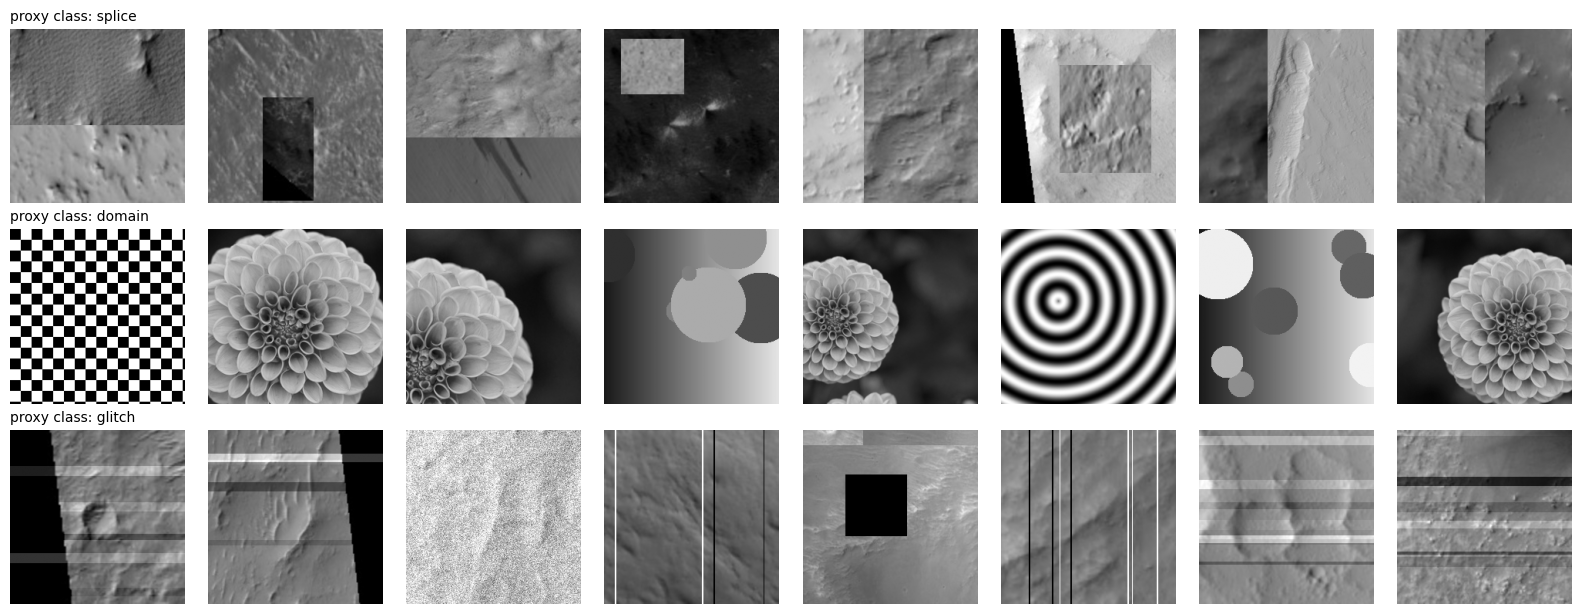

In [12]:
from sklearn.datasets import load_sample_images
from scipy.ndimage import gaussian_filter

_SAMPLE_PHOTOS = [np.asarray(Image.fromarray(a).convert("L"), dtype=np.uint8) for a in load_sample_images().images]

def make_splice(a, b, rng):
    out = a.copy()
    if rng.random() < 0.5:                                     # rectangular patch swapped in
        h, w = rng.integers(60, 150), rng.integers(60, 150)
        y, x = rng.integers(0, IMG - h), rng.integers(0, IMG - w)
        patch = b[y:y + h, x:x + w]
        if rng.random() < 0.5:
            patch = patch[:, ::-1]
        out[y:y + h, x:x + w] = patch
    else:                                                      # half-frame swap along a vertical or horizontal seam
        k = rng.integers(70, 157)
        if rng.random() < 0.5:
            out[:, k:] = b[:, k:]
        else:
            out[k:, :] = b[k:, :]
    return out

def make_glitch(a, rng):
    out = a.astype(np.float32).copy()
    kind = rng.integers(0, 4)
    if kind == 0:                                              # horizontal banding
        for _ in range(rng.integers(3, 8)):
            y0 = rng.integers(0, IMG - 15); h = rng.integers(3, 15)
            out[y0:y0 + h, :] = out[y0:y0 + h, :] * rng.uniform(0.5, 1.5) + rng.uniform(-60, 60)
    elif kind == 1:                                            # dead / saturated columns
        for _ in range(rng.integers(3, 9)):
            c = rng.integers(0, IMG - 2)
            out[:, c:c + rng.integers(1, 3)] = rng.choice([0, 255])
    elif kind == 2:                                            # heavy sensor noise
        out = out + rng.normal(0, rng.uniform(25, 55), size=out.shape)
    else:                                                      # saturated block + line shift
        s = rng.integers(40, 90); y, x = rng.integers(0, IMG - s), rng.integers(0, IMG - s)
        out[y:y + s, x:x + s] = rng.choice([0, 255])
        y1 = rng.integers(0, IMG - 20)
        out[y1:y1 + 20, :] = np.roll(out[y1:y1 + 20, :], rng.integers(20, 100), axis=1)
    return np.clip(out, 0, 255).astype(np.uint8)

def make_domain(rng):
    if rng.random() < 0.5:                                     # terrestrial photograph crop
        photo = _SAMPLE_PHOTOS[rng.integers(0, len(_SAMPLE_PHOTOS))]
        size = rng.integers(130, min(photo.shape))
        y, x = rng.integers(0, photo.shape[0] - size), rng.integers(0, photo.shape[1] - size)
        return np.asarray(Image.fromarray(photo[y:y + size, x:x + size]).resize((IMG, IMG), Image.BILINEAR), dtype=np.uint8)
    yy, xx = np.mgrid[0:IMG, 0:IMG].astype(np.float32)         # procedural man-made pattern
    kind = rng.integers(0, 3)
    if kind == 0:
        r = np.sqrt((xx - rng.integers(60, 170)) ** 2 + (yy - rng.integers(60, 170)) ** 2)
        pat = 0.5 + 0.5 * np.sin(r / rng.uniform(2, 8))
    elif kind == 1:
        s = rng.integers(8, 40)
        pat = (((xx // s) + (yy // s)) % 2).astype(np.float32)
    else:
        pat = np.tile(np.linspace(0.1, 0.9, IMG, dtype=np.float32), (IMG, 1))
        for _ in range(rng.integers(3, 8)):
            cy, cx, rad = rng.integers(0, IMG), rng.integers(0, IMG), rng.integers(10, 50)
            pat[(yy - cy) ** 2 + (xx - cx) ** 2 < rad ** 2] = rng.uniform(0, 1)
    return (255 * pat).astype(np.uint8)

def build_proxy_set(val_u8, seed=SEED):
    rng = np.random.default_rng(seed)
    n_per = int(max(8, min(100, len(val_u8) // 4)))
    bases = val_u8[:3 * n_per]
    normals = val_u8[3 * n_per:]
    images, labels, classes = [], [], []
    for i in range(n_per):
        images.append(make_splice(bases[i], bases[(i + n_per) % len(bases)], rng)); classes.append("splice")
        images.append(make_domain(rng)); classes.append("domain")
        images.append(make_glitch(bases[2 * n_per + i if 2 * n_per + i < len(bases) else i], rng)); classes.append("glitch")
    for img in normals:
        images.append(img); classes.append("normal")
    classes = np.array(classes)
    return np.stack(images), (classes != "normal").astype(int), classes

PROXY_U8, PROXY_Y, PROXY_CLS = build_proxy_set(X_u8[val_np])
print("proxy set:", {c: int((PROXY_CLS == c).sum()) for c in ["normal", "splice", "domain", "glitch"]})

fig, axes = plt.subplots(3, 8, figsize=(16, 6.2))
for row, cls in enumerate(["splice", "domain", "glitch"]):
    sel = np.where(PROXY_CLS == cls)[0][:8]
    for a, j in zip(axes[row], sel):
        a.imshow(PROXY_U8[j], cmap="gray", vmin=0, vmax=255); a.axis("off")
    axes[row][0].set_title(f"proxy class: {cls}", loc="left", fontsize=10)
plt.tight_layout(); plt.show()


def proxy_eval(model, standardize, train_indices):
    """Fit an Isolation Forest on training latents, score normals + proxy anomalies, return AUROC / AP."""
    Z_train = encode_idx(model, train_indices[:5000])
    Z_proxy = encode_array(model, PROXY_U8)
    scaler = StandardScaler().fit(Z_train) if standardize else None
    if scaler is not None:
        Z_train, Z_proxy = scaler.transform(Z_train), scaler.transform(Z_proxy)
    forest = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED, n_jobs=-1).fit(Z_train)
    scores = -forest.score_samples(Z_proxy)               # higher = more anomalous
    result = {"auroc": roc_auc_score(PROXY_Y, scores), "ap": average_precision_score(PROXY_Y, scores)}
    for cls in ["splice", "domain", "glitch"]:
        mask = (PROXY_CLS == cls) | (PROXY_CLS == "normal")
        result["auroc_" + cls] = roc_auc_score((PROXY_CLS[mask] == cls).astype(int), scores[mask])
    return result

### 1.1 (continued) Justifying the latent dimensionality
Latent size trades **reconstruction fidelity** (bigger = better SSIM/MSE) against **outlier separability** (a bigger latent also encodes nuisance detail and dilutes Isolation-Forest splits). We train the same v2-style model for several sizes and compare reconstruction quality with the proxy-anomaly AUROC.

--- latent_dim = 32 ---


  val SSIM 0.6051 | val MSE 0.03533 | proxy AUROC 0.685
--- latent_dim = 64 ---


  val SSIM 0.6056 | val MSE 0.03411 | proxy AUROC 0.782


,latent_dim,val_mse,val_ssim,proxy_auroc,proxy_ap
0,32,0.0353,0.6051,0.6845,0.8385
1,64,0.0341,0.6056,0.7817,0.8969


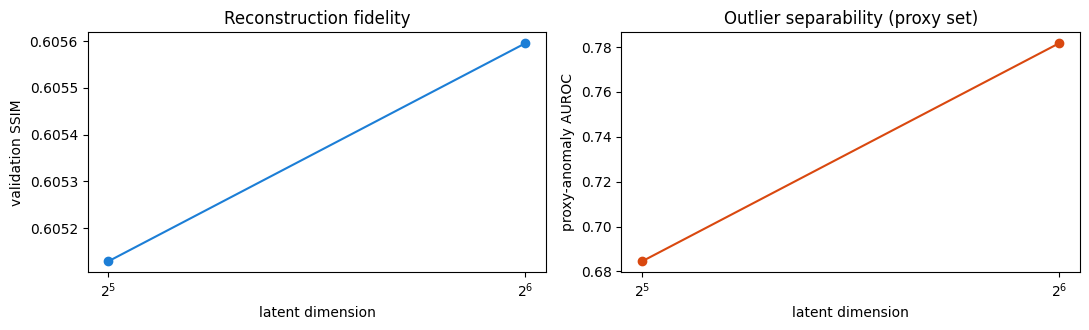


CHOSEN latent_dim = 64 (highest proxy AUROC 0.782, val SSIM 0.6056)


In [13]:
sweep_rows = []
sweep_train = train_idx[torch.randperm(len(train_idx), device=train_idx.device)[:SWEEP_N]]
for dim in LATENT_SWEEP:
    print(f"--- latent_dim = {dim} ---")
    m, _ = train_model(f"sweep-{dim}", variational=False, loss_mode="mse_ssim", latent_dim=dim,
                       epochs=SWEEP_EPOCHS, train_indices=sweep_train, val_indices=val_idx, verbose=False)
    rm = recon_metrics(m, val_idx)
    pe = proxy_eval(m, standardize=False, train_indices=sweep_train)
    sweep_rows.append({"latent_dim": dim, "val_mse": rm["val_mse"], "val_ssim": rm["val_ssim"],
                       "proxy_auroc": pe["auroc"], "proxy_ap": pe["ap"]})
    print(f"  val SSIM {rm['val_ssim']:.4f} | val MSE {rm['val_mse']:.5f} | proxy AUROC {pe['auroc']:.3f}")
    del m
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(sweep_df["latent_dim"], sweep_df["val_ssim"], "o-", color="#1c7ed6"); ax[0].set_xscale("log", base=2)
ax[0].set_xlabel("latent dimension"); ax[0].set_ylabel("validation SSIM"); ax[0].set_title("Reconstruction fidelity")
ax[1].plot(sweep_df["latent_dim"], sweep_df["proxy_auroc"], "o-", color="#d9480f"); ax[1].set_xscale("log", base=2)
ax[1].set_xlabel("latent dimension"); ax[1].set_ylabel("proxy-anomaly AUROC"); ax[1].set_title("Outlier separability (proxy set)")
plt.tight_layout(); plt.show()

best_row = sweep_df.sort_values(["proxy_auroc", "latent_dim"], ascending=[False, True]).iloc[0]
LATENT_DIM = int(LATENT_DIM_OVERRIDE or best_row["latent_dim"])
print(f"\nCHOSEN latent_dim = {LATENT_DIM}",
      "(override)" if LATENT_DIM_OVERRIDE else f"(highest proxy AUROC {best_row['proxy_auroc']:.3f}, "
      f"val SSIM {best_row['val_ssim']:.4f})")

### Training the three iterations (v1 -> v2 -> v3)
Each version changes **one thing**, so the effect can be attributed (details and measured evidence are written up in Phase 4):

| Version | Model | Loss | Latent given to Isolation Forest |
|---|---|---|---|
| **v1** baseline | CAE | MSE | raw latent |
| **v2** | CAE | 10 x MSE + (1 - SSIM) | raw latent |
| **v3** | VAE (KL-regularised) | 10 x MSE + (1 - SSIM) + beta x KL | standardised mean latent |

In [14]:
VERSIONS = {
    "v1": dict(variational=False, loss_mode="mse",      standardize=False),
    "v2": dict(variational=False, loss_mode="mse_ssim", standardize=False),
    "v3": dict(variational=True,  loss_mode="mse_ssim", standardize=True),
}
all_idx = torch.arange(N, device=DEVICE)

models, histories, latents_all, version_rows = {}, {}, {}, []
for vname, cfg in VERSIONS.items():
    print(f"\n================  {vname}  ================")
    model, hist = train_model(vname, cfg["variational"], cfg["loss_mode"], LATENT_DIM, EPOCHS, train_idx, val_idx)
    models[vname], histories[vname] = model, hist
    latents_all[vname] = encode_idx(model, all_idx)

    rm = recon_metrics(model, val_idx)
    pe = proxy_eval(model, cfg["standardize"], train_idx)
    diag = latent_diagnostics(latents_all[vname])
    version_rows.append({"version": vname, "val_mse": rm["val_mse"], "val_ssim": rm["val_ssim"],
                         "sharpness_ratio": rm["sharpness_ratio"], **diag,
                         "proxy_auroc": pe["auroc"], "proxy_ap": pe["ap"],
                         "auroc_splice": pe["auroc_splice"], "auroc_domain": pe["auroc_domain"],
                         "auroc_glitch": pe["auroc_glitch"]})
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

version_df = pd.DataFrame(version_rows).set_index("version")
display(version_df.round(4))

# automatic final-version choice (highest proxy AUROC) unless forced
FINAL = version_df["proxy_auroc"].idxmax() if FINAL_VERSION == "auto" else FINAL_VERSION
print(f"\nFINAL VERSION used for Phases 2-3 and inference: {FINAL}  "
      f"({'best proxy AUROC' if FINAL_VERSION == 'auto' else 'forced'})")
final_model = models[FINAL]
final_cfg = VERSIONS[FINAL]
Z = latents_all[FINAL]


================  v1  ================


[v1] epoch 01/2  loss 0.0232  val MSE 0.03387  val SSIM 0.5983  (1s)


[v1] epoch 02/2  loss 0.0146  val MSE 0.04784  val SSIM 0.5322  (0s)



================  v2  ================


[v2] epoch 01/2  loss 0.8196  val MSE 0.03404  val SSIM 0.6056  (1s)


...


================  v3  ================


[v3] epoch 01/2  loss 0.8176  val MSE 0.03469  val SSIM 0.6050  (1s)


[v3] epoch 02/2  loss 0.6018  val MSE 0.03592  val SSIM 0.6032  (1s)


,val_mse,val_ssim,sharpness_ratio,participation_ratio,std_cv,proxy_auroc,proxy_ap,auroc_splice,auroc_domain,auroc_glitch
version,,,,,,,,,,
v1,0.0478,0.5322,1.0715,1.2254,0.5723,0.7302,0.8731,0.6905,0.8571,0.6429
v2,0.0333,0.6047,0.1281,1.0301,0.6225,0.7976,0.9025,0.6964,0.9524,0.7440
v3,0.0359,0.6032,0.1695,1.4325,0.5726,0.7857,0.9152,0.7381,0.9821,0.6369



FINAL VERSION used for Phases 2-3 and inference: v2  (best proxy AUROC)


## 1.3 Latent Space Visualisation
UMAP (all crops) and t-SNE (subsample) projections of the final latent vectors. **These are qualitative diagnostics only**: they are not proof of geological clustering, and a single dense blob would be a reason to investigate, not conclusive evidence of encoder collapse. Colours below are *visual aids* (brightness, resolution, latitude from the provided metadata), not labels.

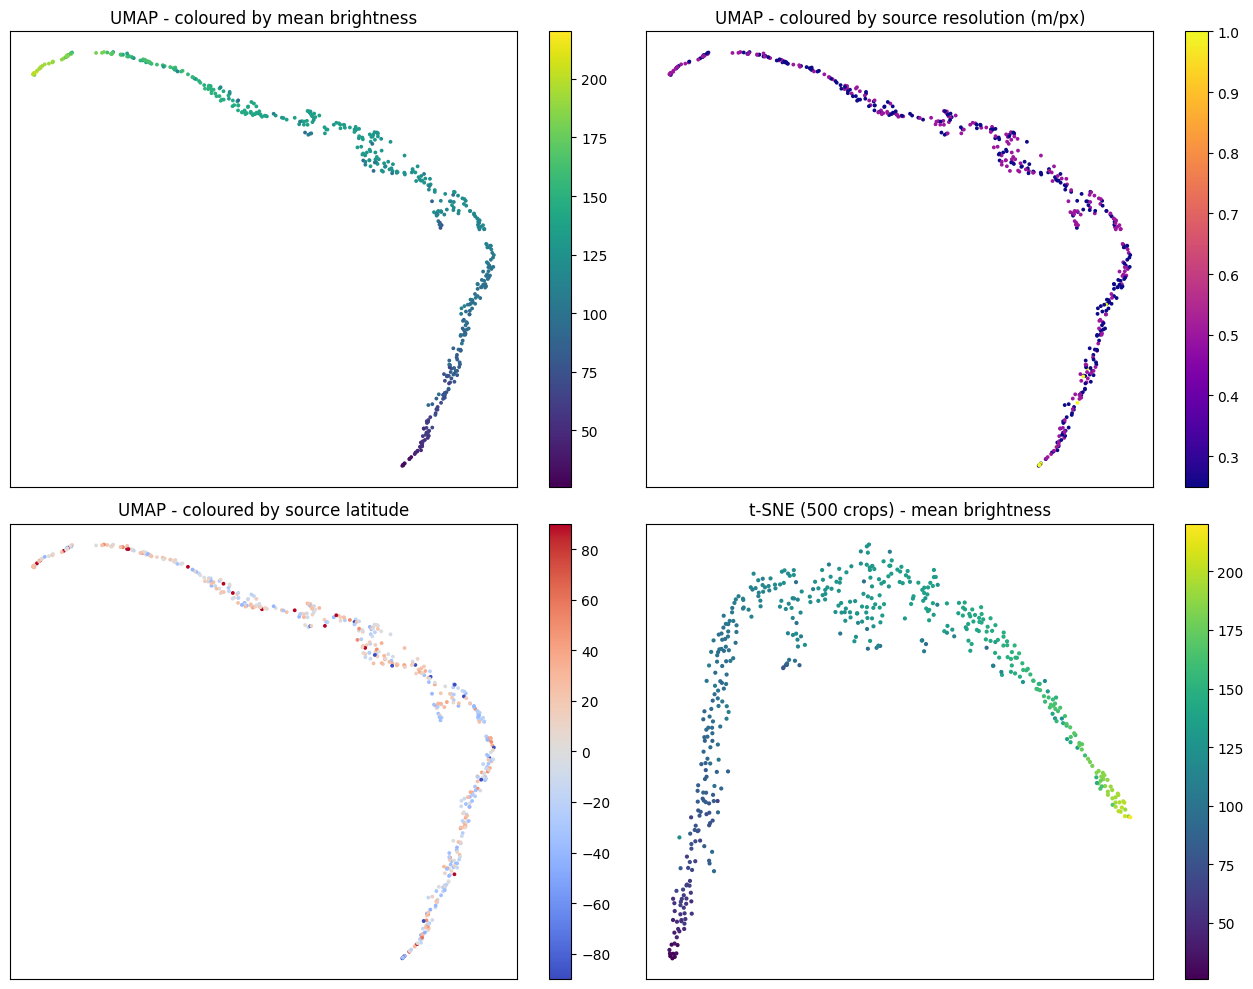

latent diagnostics -> participation ratio (effective dims): 1.0 of 64 | per-dimension scale CV: 0.62
Interpretation guide: a participation ratio close to 1 would suggest the code uses almost one direction (possible collapse); a structureless single blob should be investigated, but is not proof by itself.


In [15]:
import umap
from sklearn.manifold import TSNE

Z_vis = StandardScaler().fit_transform(Z) if final_cfg["standardize"] else Z
umap_2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=SEED, n_jobs=1).fit_transform(Z_vis)

n_tsne = min(len(Z_vis), 800 if QUICK_TEST else 4000)
tsne_idx = np.random.default_rng(SEED).choice(len(Z_vis), n_tsne, replace=False)
tsne_2d = TSNE(n_components=2, perplexity=min(30, n_tsne // 4), init="pca", random_state=SEED).fit_transform(Z_vis[tsne_idx])

meta_vis = df_crop.merge(df_src, on="source_image_id", how="left")
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
sc = ax[0, 0].scatter(umap_2d[:, 0], umap_2d[:, 1], c=img_mean, s=3, cmap="viridis"); ax[0, 0].set_title("UMAP - coloured by mean brightness")
plt.colorbar(sc, ax=ax[0, 0])
sc = ax[0, 1].scatter(umap_2d[:, 0], umap_2d[:, 1], c=meta_vis["resolution"], s=3, cmap="plasma"); ax[0, 1].set_title("UMAP - coloured by source resolution (m/px)")
plt.colorbar(sc, ax=ax[0, 1])
sc = ax[1, 0].scatter(umap_2d[:, 0], umap_2d[:, 1], c=meta_vis["latitude"], s=3, cmap="coolwarm"); ax[1, 0].set_title("UMAP - coloured by source latitude")
plt.colorbar(sc, ax=ax[1, 0])
sc = ax[1, 1].scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=img_mean[tsne_idx], s=4, cmap="viridis"); ax[1, 1].set_title(f"t-SNE ({n_tsne} crops) - mean brightness")
plt.colorbar(sc, ax=ax[1, 1])
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

diag = latent_diagnostics(Z)
print(f"latent diagnostics -> participation ratio (effective dims): {diag['participation_ratio']:.1f} of {Z.shape[1]} | "
      f"per-dimension scale CV: {diag['std_cv']:.2f}")
print("Interpretation guide: a participation ratio close to 1 would suggest the code uses almost one direction (possible collapse); "
      "a structureless single blob should be investigated, but is not proof by itself.")

# Phase 2 - Isolation Forest Novelty Engine
## 2.1 Novelty Scoring
The Isolation Forest is fitted on the **Phase 1 latent vectors** (never raw pixels). scikit-learn's `score_samples` returns *higher = more normal*, which is the opposite of the competition convention, so we use

**Novelty Score = - score_samples(z)**  (higher = more anomalous)

`contamination` is kept at `"auto"` and is **not** used to decide how many images are flagged; the final cut-off comes from the score distribution in 2.2.

IsolationForest parameters: n_estimators=300, max_samples='auto', contamination='auto' (not used to set the final count)
novelty score range: 0.3486 .. 0.8278 | median 0.3733
sign check -> mean novelty: proxy anomalies 0.4934 vs proxy normals 0.3955


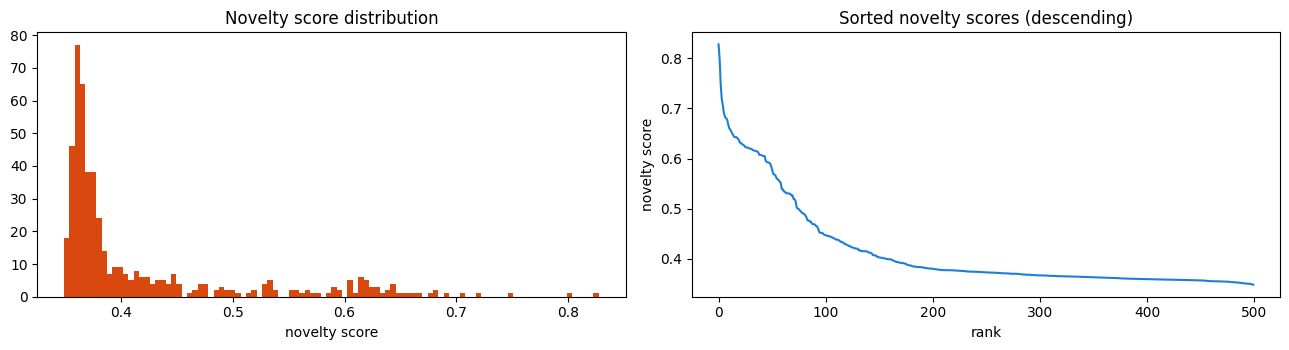

In [16]:
Z_if = Z
scaler_final = None
if final_cfg["standardize"]:
    scaler_final = StandardScaler().fit(Z)
    Z_if = scaler_final.transform(Z)

iforest = IsolationForest(n_estimators=300, max_samples="auto", contamination="auto",
                          random_state=SEED, n_jobs=-1).fit(Z_if)
novelty = -iforest.score_samples(Z_if)          # competition convention: higher = more anomalous
print("IsolationForest parameters: n_estimators=300, max_samples='auto', contamination='auto' (not used to set the final count)")
print(f"novelty score range: {novelty.min():.4f} .. {novelty.max():.4f} | median {np.median(novelty):.4f}")

# sign-convention sanity check on the proxy set (anomalies must score higher than normals)
Z_proxy_chk = encode_array(final_model, PROXY_U8)
if scaler_final is not None:
    Z_proxy_chk = scaler_final.transform(Z_proxy_chk)
proxy_scores = -iforest.score_samples(Z_proxy_chk)
print(f"sign check -> mean novelty: proxy anomalies {proxy_scores[PROXY_Y == 1].mean():.4f} vs proxy normals "
      f"{proxy_scores[PROXY_Y == 0].mean():.4f}")
assert proxy_scores[PROXY_Y == 1].mean() > proxy_scores[PROXY_Y == 0].mean(), "score sign looks inverted"

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].hist(novelty, bins=100, color="#d9480f"); ax[0].set_title("Novelty score distribution"); ax[0].set_xlabel("novelty score")
ax[1].plot(np.sort(novelty)[::-1], color="#1c7ed6"); ax[1].set_title("Sorted novelty scores (descending)")
ax[1].set_xlabel("rank"); ax[1].set_ylabel("novelty score")
plt.tight_layout(); plt.show()

## 2.2 Statistical Thresholding
**No fixed top-N and no assumed contamination.** We examine the observed score distribution first, then justify one boundary.

1. **Is the distribution Gaussian?** If not, mu + k sigma is unjustified (checked below with skewness, excess kurtosis, a D'Agostino normality test and the tail mass beyond mu + 3 sigma).
2. **Primary method - robust modified z-score:** `M_i = 0.6745 (x_i - median) / MAD`, flag if `M_i > 3.5` (Iglewicz & Hoaglin, 1993). Median and MAD are not inflated by the very outliers we search for, and no Gaussian assumption is made about the bulk.
3. **Cross-checks:** (a) *elbow* of the sorted score curve using the Kneedle algorithm (normalise the curve to the unit square, take the point of maximum distance from the chord), (b) *KDE valley* between the main mode and the tail, (c) classic mu + 3 sigma for comparison.

skewness 1.93 | excess kurtosis 2.97 | D'Agostino normality p = 1.48e-41
mass above mu+3sigma: observed 1.40%  vs  0.13% expected for a Gaussian
=> Gaussian assumption REJECTED: mu + k*sigma is not directly justified


,method,threshold,n_flagged,percent
0,mad,0.4496,98,19.6
1,sigma,0.6827,7,1.4
2,knee,0.6428,15,3.0
3,kde,0.5582,56,11.2



FINAL THRESHOLD (mad) = 0.44965  ->  98 images flagged (19.60% of 500)
IsolationForest contamination = 'auto'. The anomaly count above was NOT assumed: it is the number of images whose
novelty score exceeds a boundary derived from the observed score distribution (median + 3.5 * MAD / 0.6745).


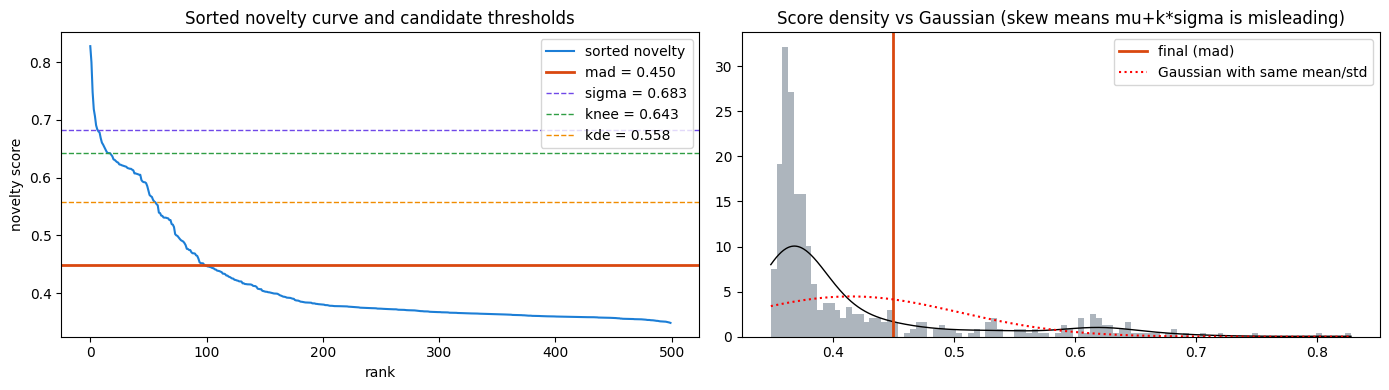

In [17]:
from scipy import stats
from scipy.signal import find_peaks
from kneed import KneeLocator

# --- 1. distribution check ---
skew = stats.skew(novelty); exkurt = stats.kurtosis(novelty)
normal_p = stats.normaltest(novelty).pvalue
mu, sd = novelty.mean(), novelty.std()
tail_obs = (novelty > mu + 3 * sd).mean()
print(f"skewness {skew:.2f} | excess kurtosis {exkurt:.2f} | D'Agostino normality p = {normal_p:.2e}")
print(f"mass above mu+3sigma: observed {100 * tail_obs:.2f}%  vs  0.13% expected for a Gaussian")
print("=> Gaussian assumption", "REJECTED: mu + k*sigma is not directly justified" if normal_p < 0.01 else "not rejected")

# --- 2. candidate thresholds ---
sorted_desc = np.sort(novelty)[::-1]
med = np.median(novelty)
mad = np.median(np.abs(novelty - med))
thr_mad = med + MAD_K * mad / 0.6745
thr_sigma = mu + 3 * sd

try:
    knee = KneeLocator(np.arange(len(sorted_desc)), sorted_desc, curve="convex", direction="decreasing", S=1.0)
    thr_knee = float(sorted_desc[knee.knee]) if knee.knee is not None else None
except Exception:
    thr_knee = None

grid = np.linspace(novelty.min(), novelty.max(), 1000)
density = stats.gaussian_kde(novelty)(grid)
mode_i = int(np.argmax(density))
valleys, _ = find_peaks(-density, prominence=0.02 * density.max())
valleys = valleys[valleys > mode_i]
thr_kde = float(grid[valleys[0]]) if len(valleys) else None

candidates = {"mad": thr_mad, "sigma": thr_sigma, "knee": thr_knee, "kde": thr_kde}
rows = []
for name, thr in candidates.items():
    rows.append({"method": name, "threshold": thr, "n_flagged": int((novelty > thr).sum()) if thr is not None else None,
                 "percent": 100 * (novelty > thr).mean() if thr is not None else None})
thr_table = pd.DataFrame(rows)
display(thr_table.round(4))

# --- 3. final choice ---
THRESHOLD = candidates[THRESHOLD_METHOD]
if THRESHOLD is None:
    print(f"method '{THRESHOLD_METHOD}' found no boundary on this distribution -> falling back to 'mad'")
    THRESHOLD_METHOD, THRESHOLD = "mad", thr_mad
flagged_mask = novelty > THRESHOLD
n_flagged = int(flagged_mask.sum())
print(f"\nFINAL THRESHOLD ({THRESHOLD_METHOD}) = {THRESHOLD:.5f}  ->  {n_flagged} images flagged ({100 * n_flagged / N:.2f}% of {N})")
print("IsolationForest contamination = 'auto'. The anomaly count above was NOT assumed: it is the number of images whose")
print("novelty score exceeds a boundary derived from the observed score distribution (median + 3.5 * MAD / 0.6745).")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(sorted_desc, color="#1c7ed6", label="sorted novelty")
colors = {"mad": "#d9480f", "sigma": "#7048e8", "knee": "#2f9e44", "kde": "#f08c00"}
for name, thr in candidates.items():
    if thr is not None:
        ax[0].axhline(thr, color=colors[name], ls="--" if name != THRESHOLD_METHOD else "-", lw=2 if name == THRESHOLD_METHOD else 1,
                      label=f"{name} = {thr:.3f}")
ax[0].set_xlabel("rank"); ax[0].set_ylabel("novelty score"); ax[0].set_title("Sorted novelty curve and candidate thresholds"); ax[0].legend()
ax[1].hist(novelty, bins=100, density=True, color="#adb5bd")
ax[1].plot(grid, density, color="black", lw=1)
ax[1].axvline(THRESHOLD, color=colors[THRESHOLD_METHOD], lw=2, label=f"final ({THRESHOLD_METHOD})")
xs = np.linspace(novelty.min(), novelty.max(), 400)
ax[1].plot(xs, stats.norm.pdf(xs, mu, sd), "r:", label="Gaussian with same mean/std")
ax[1].set_title("Score density vs Gaussian (skew means mu+k*sigma is misleading)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2.3 Image Location Analysis
Each novelty-scored crop is joined to `source_image_metadata.csv` through `source_image_id`. Since outliers were injected at random positions, a strong dependence on acquisition conditions would show that the model is *sensitive to those conditions* (a confound), which is itself useful to know.

joined table: (500, 9) | unique sources: 136


,n,flagged,rate,mean_novelty
season,,,,
N-autumn,105,14,0.1333,0.3997
N-spring,197,42,0.2132,0.4201
N-summer,152,34,0.2237,0.4217
N-winter,46,8,0.1739,0.4042


,n,flagged,rate,mean_novelty
resolution,,,,
0.25,255,49,0.1922,0.4098
0.50,237,49,0.2068,0.4211
1.00,8,0,0.0000,0.3891


season vs flagged (chi-square) p = 0.2761
sun_angle flagged vs rest (Mann-Whitney) p = 0.0000
Spearman(sun_angle, novelty) = -0.113 (p = 1.11e-02)

Source observations with the highest flag rate (n >= 10 crops):


,n,flagged,rate,mean_novelty,latitude,longitude,season,sun_angle
source_image_id,,,,,,,,
SRC_124,10,3,0.300,0.430,0.0,180.0,N-summer,51.928
SRC_091,10,2,0.200,0.426,-40.0,180.0,N-summer,72.511
SRC_009,12,1,0.083,0.382,-25.0,180.0,N-spring,73.828
SRC_004,10,0,0.000,0.361,30.0,180.0,N-autumn,61.107


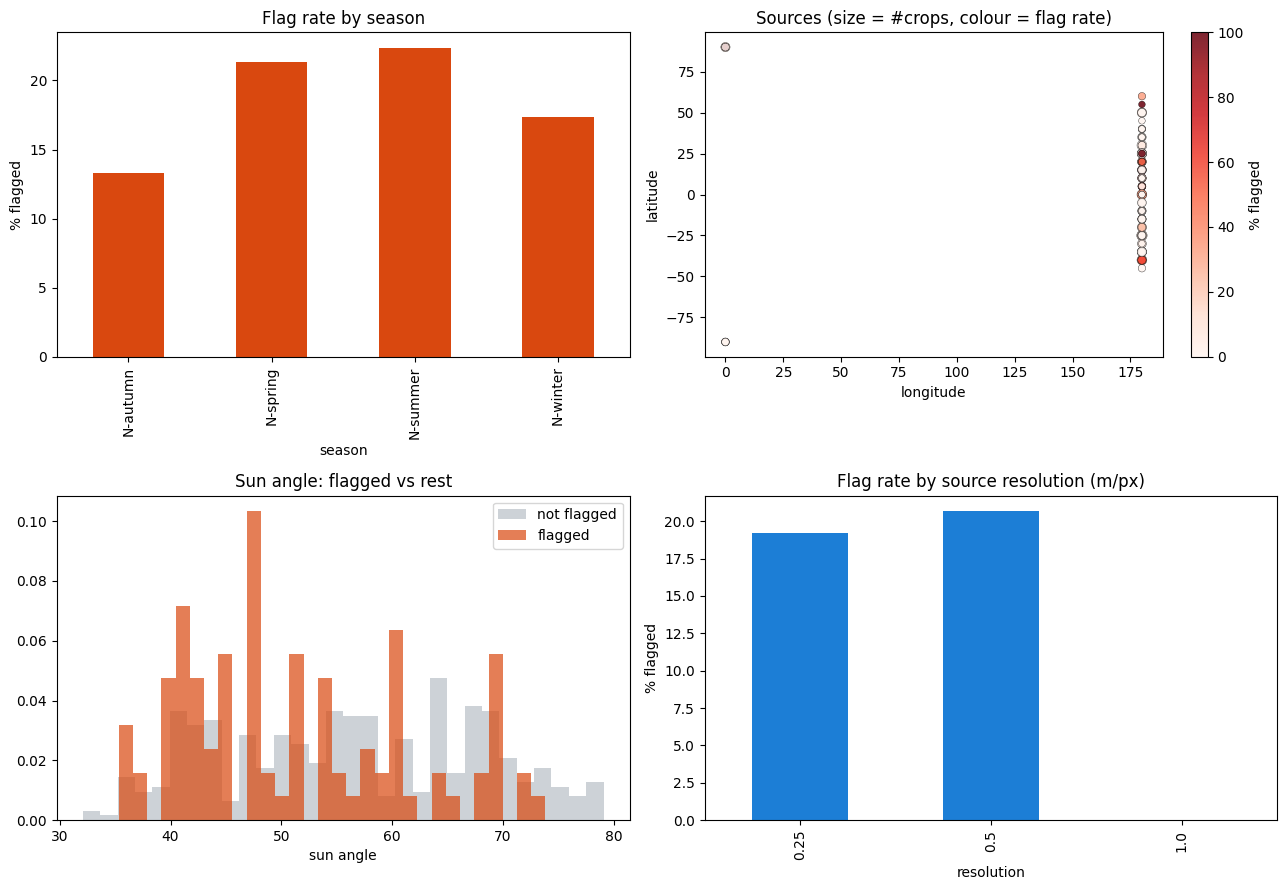

In [18]:
scored = df_crop.copy()
scored["novelty"] = novelty
scored["flagged"] = flagged_mask
scored = scored.merge(df_src, on="source_image_id", how="left")
assert len(scored) == N and scored["latitude"].notna().all(), "metadata join lost rows"
print("joined table:", scored.shape, "| unique sources:", scored["source_image_id"].nunique())

# per-season and per-resolution flag rates
season_tbl = scored.groupby("season").agg(n=("flagged", "size"), flagged=("flagged", "sum"), rate=("flagged", "mean"), mean_novelty=("novelty", "mean"))
res_tbl = scored.groupby("resolution").agg(n=("flagged", "size"), flagged=("flagged", "sum"), rate=("flagged", "mean"), mean_novelty=("novelty", "mean"))
display(season_tbl.round(4)); display(res_tbl.round(4))

# statistical tests (guarded for tiny samples)
ct = pd.crosstab(scored["season"], scored["flagged"])
if ct.shape[1] == 2 and ct.shape[0] > 1:
    chi2_p = stats.chi2_contingency(ct)[1]
    print(f"season vs flagged (chi-square) p = {chi2_p:.4f}")
if scored["flagged"].sum() >= 3:
    u_p = stats.mannwhitneyu(scored.loc[scored["flagged"], "sun_angle"], scored.loc[~scored["flagged"], "sun_angle"]).pvalue
    print(f"sun_angle flagged vs rest (Mann-Whitney) p = {u_p:.4f}")
sp = stats.spearmanr(scored["sun_angle"], scored["novelty"])
print(f"Spearman(sun_angle, novelty) = {sp[0]:.3f} (p = {sp[1]:.2e})")

# per-source table (min 10 crops so rates are not driven by tiny sources)
src_tbl = (scored.groupby("source_image_id")
           .agg(n=("flagged", "size"), flagged=("flagged", "sum"), rate=("flagged", "mean"), mean_novelty=("novelty", "mean"),
                latitude=("latitude", "first"), longitude=("longitude", "first"), season=("season", "first"), sun_angle=("sun_angle", "first"))
           .query("n >= 10").sort_values("rate", ascending=False))
print("\nSource observations with the highest flag rate (n >= 10 crops):")
display(src_tbl.head(10).round(3))

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
season_tbl["rate"].mul(100).plot.bar(ax=ax[0, 0], color="#d9480f"); ax[0, 0].set_ylabel("% flagged"); ax[0, 0].set_title("Flag rate by season")
src_all = scored.groupby("source_image_id").agg(rate=("flagged", "mean"), n=("flagged", "size"), lat=("latitude", "first"), lon=("longitude", "first"))
sc = ax[0, 1].scatter(src_all["lon"], src_all["lat"], c=100 * src_all["rate"], s=20 + 3 * src_all["n"], cmap="Reds", edgecolor="k", linewidth=0.3, alpha=0.85)
plt.colorbar(sc, ax=ax[0, 1], label="% flagged"); ax[0, 1].set_xlabel("longitude"); ax[0, 1].set_ylabel("latitude"); ax[0, 1].set_title("Sources (size = #crops, colour = flag rate)")
ax[1, 0].hist(scored.loc[~scored["flagged"], "sun_angle"], bins=30, density=True, alpha=0.6, label="not flagged", color="#adb5bd")
if scored["flagged"].any():
    ax[1, 0].hist(scored.loc[scored["flagged"], "sun_angle"], bins=30, density=True, alpha=0.7, label="flagged", color="#d9480f")
ax[1, 0].set_xlabel("sun angle"); ax[1, 0].set_title("Sun angle: flagged vs rest"); ax[1, 0].legend()
res_tbl["rate"].mul(100).plot.bar(ax=ax[1, 1], color="#1c7ed6"); ax[1, 1].set_ylabel("% flagged"); ax[1, 1].set_title("Flag rate by source resolution (m/px)")
plt.tight_layout(); plt.show()

## 2.4 Optional Metadata Fusion (+2)
The image-only pipeline above stays the primary result. Here the standardised latent is **concatenated with a metadata vector** (z-scored sun angle + one-hot season, group-weighted so metadata contributes a fixed fraction of the total variance) and a second Isolation Forest is fitted. We report how the flagged set changes.

In [19]:
Z_std = StandardScaler().fit_transform(Z)
sun_z = ((scored["sun_angle"] - scored["sun_angle"].mean()) / scored["sun_angle"].std()).to_numpy()[:, None]
season_oh = pd.get_dummies(scored["season"]).to_numpy(dtype=np.float32)
meta_vec = np.hstack([sun_z, season_oh]).astype(np.float32)

META_FRACTION = 0.25                                   # share of the total variance given to the metadata group
w_meta = math.sqrt(META_FRACTION / (1 - META_FRACTION) * Z_std.shape[1] / meta_vec.shape[1])
fused = np.hstack([Z_std, w_meta * meta_vec])

forest_fused = IsolationForest(n_estimators=300, contamination="auto", random_state=SEED, n_jobs=-1).fit(fused)
novelty_fused = -forest_fused.score_samples(fused)
med_f = np.median(novelty_fused); mad_f = np.median(np.abs(novelty_fused - med_f))
thr_fused = med_f + MAD_K * mad_f / 0.6745
flag_fused = novelty_fused > thr_fused

a, b = set(np.where(flagged_mask)[0]), set(np.where(flag_fused)[0])
jaccard = len(a & b) / max(1, len(a | b))
print(f"image-only flagged: {len(a)} | fused flagged: {len(b)} | overlap: {len(a & b)} | Jaccard: {jaccard:.2f}")
print(f"newly flagged by fusion: {len(b - a)} | dropped by fusion: {len(a - b)}")
print(f"Spearman rank correlation of the two novelty scores: {stats.spearmanr(novelty, novelty_fused)[0]:.3f}")
changed = scored.loc[sorted(a ^ b), ["filename", "source_image_id", "season", "sun_angle"]].copy()
changed["image_only_flag"] = [i in a for i in changed.index]
changed["fused_flag"] = [i in b for i in changed.index]
display(changed.head(15))

image-only flagged: 98 | fused flagged: 90 | overlap: 90 | Jaccard: 0.92
newly flagged by fusion: 0 | dropped by fusion: 8
Spearman rank correlation of the two novelty scores: 0.934


,filename,source_image_id,season,sun_angle,image_only_flag,fused_flag
32,sample_02515.jpg,SRC_133,N-spring,48.887369,True,False
52,sample_05769.jpg,SRC_009,N-spring,73.827745,True,False
90,sample_04756.jpg,SRC_112,N-spring,67.516648,True,False
143,sample_00304.jpg,SRC_006,N-spring,65.638079,True,False
218,sample_04029.jpg,SRC_082,N-spring,60.444036,True,False
355,sample_01651.jpg,SRC_052,N-summer,51.705435,True,False
402,sample_00470.jpg,SRC_131,N-autumn,60.540464,True,False
443,sample_01091.jpg,SRC_138,N-summer,44.714676,True,False


# Phase 3 - Reconstruction Interpretability
## 3.1 Pixel-Wise Error Heatmaps
After the statistical threshold of 2.2, flagged images are **ranked by novelty score** and the **five most anomalous** of that thresholded set are selected (fewer if fewer than five exceed the threshold - the threshold is never lowered to reach five). Each selected crop is passed through the Phase 1 encoder + decoder, and the absolute pixel error `|original - reconstruction|` is rendered as a jet overlay (Gaussian-smoothed, normalised to its 99th percentile for visibility).

98 images exceed the threshold; analysing the top 5


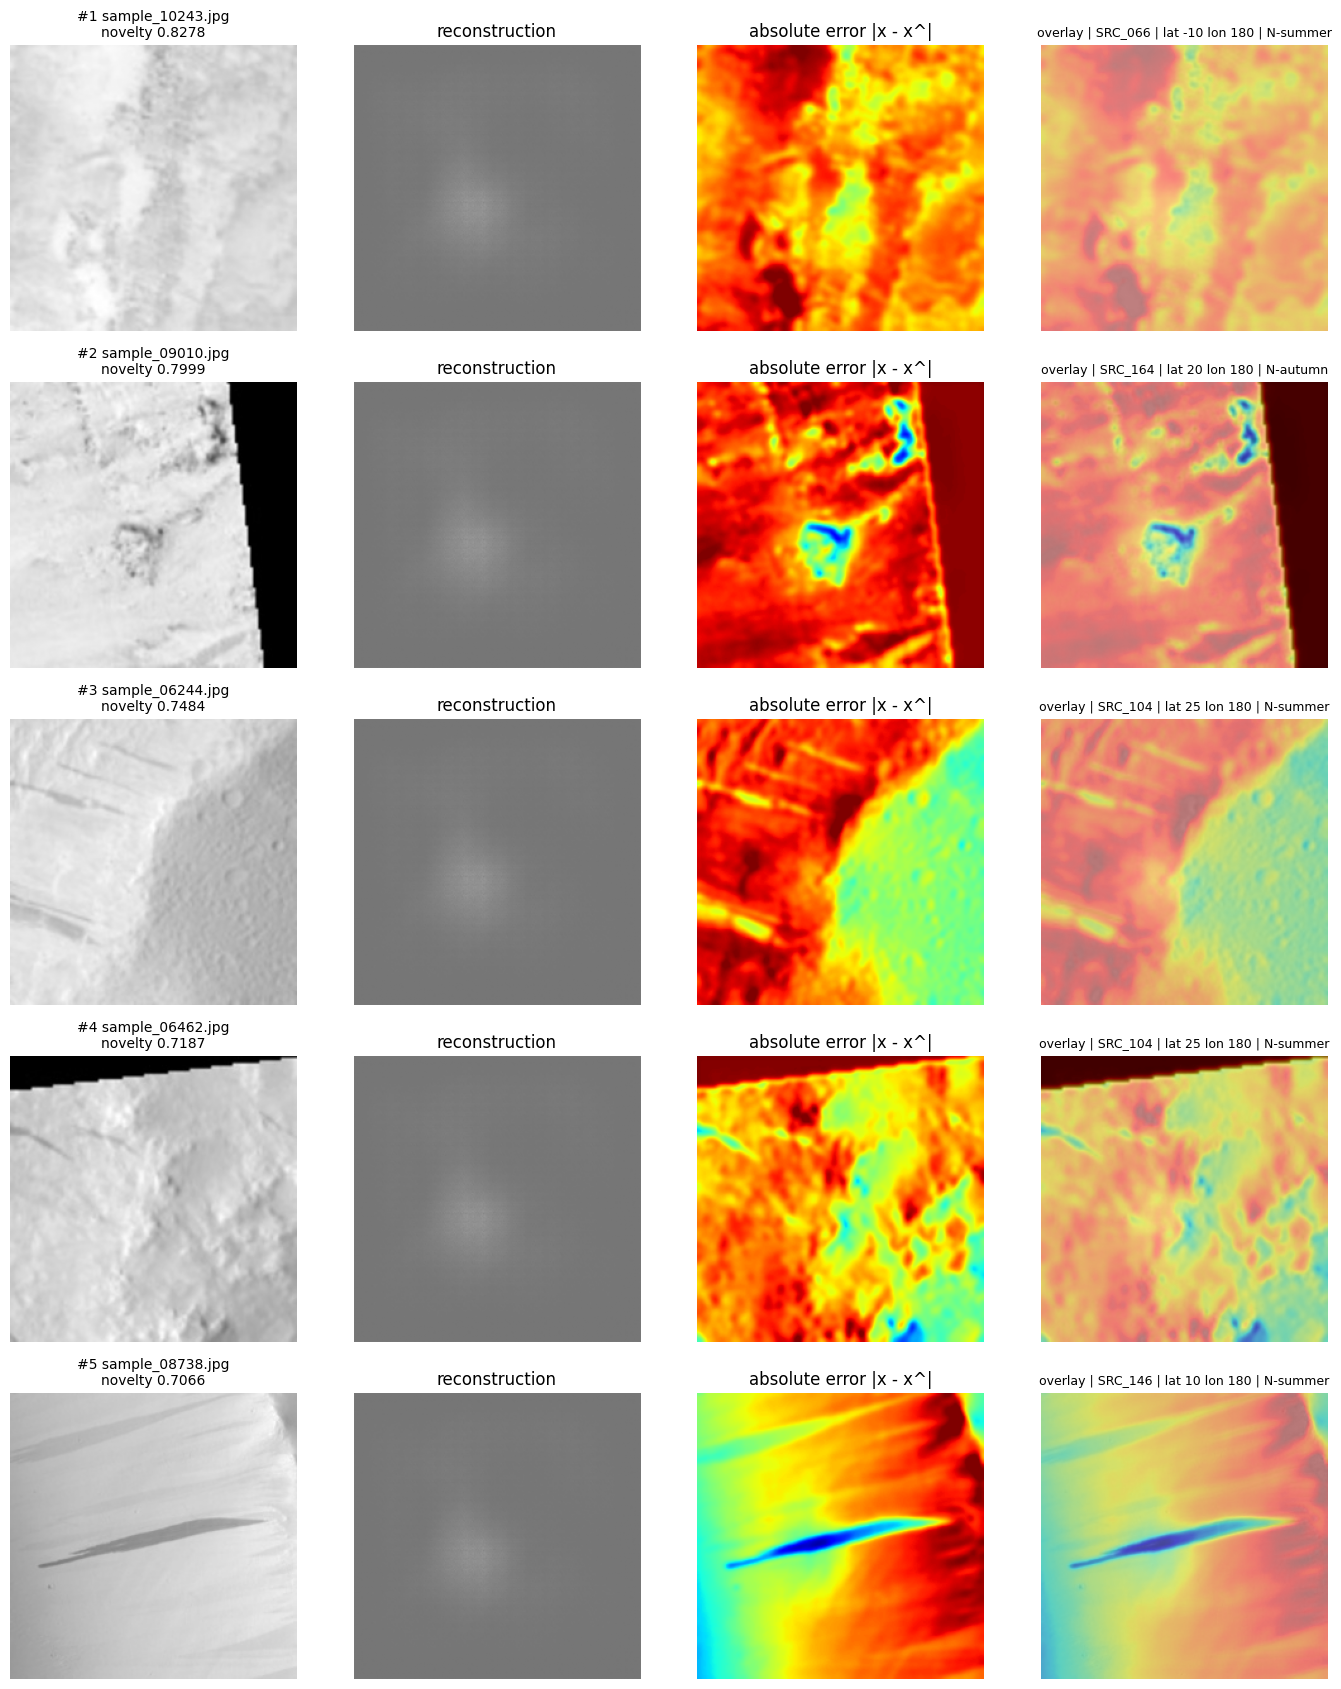

In [20]:
from scipy.ndimage import gaussian_filter

ranked = scored[scored["flagged"]].sort_values("novelty", ascending=False)
top_df = ranked.head(5)
print(f"{len(ranked)} images exceed the threshold; analysing the top {len(top_df)}"
      + ("" if len(ranked) >= 5 else " (fewer than 5 exceed the threshold, so all are analysed)"))

@torch.no_grad()
def reconstruct_rows(model, row_indices):
    model.eval()
    xb = X[torch.as_tensor(list(row_indices), device=DEVICE)].float() / 255.0
    rb, _, _ = model(xb)
    return xb[:, 0].cpu().numpy(), rb[:, 0].cpu().numpy()

if len(top_df) > 0:
    orig_stack, recon_stack = reconstruct_rows(final_model, top_df.index.tolist())
    fig, axes = plt.subplots(len(top_df), 4, figsize=(14, 3.4 * len(top_df)), squeeze=False)
    for r, (row_idx, rec) in enumerate(top_df.iterrows()):
        o, rc = orig_stack[r], recon_stack[r]
        err = gaussian_filter(np.abs(o - rc), sigma=2.0)
        err_n = np.clip(err / max(np.percentile(err, 99), 1e-9), 0, 1)
        axes[r, 0].imshow(o, cmap="gray", vmin=0, vmax=1); axes[r, 0].set_title(f"#{r + 1} {rec['filename']}\nnovelty {rec['novelty']:.4f}", fontsize=10)
        axes[r, 1].imshow(rc, cmap="gray", vmin=0, vmax=1); axes[r, 1].set_title("reconstruction")
        im = axes[r, 2].imshow(err_n, cmap="jet", vmin=0, vmax=1); axes[r, 2].set_title("absolute error |x - x^|")
        axes[r, 3].imshow(o, cmap="gray", vmin=0, vmax=1); axes[r, 3].imshow(err_n, cmap="jet", alpha=0.5, vmin=0, vmax=1)
        axes[r, 3].set_title(f"overlay | {rec['source_image_id']} | lat {rec['latitude']:.0f} lon {rec['longitude']:.0f} | {rec['season']}", fontsize=9)
        for a in axes[r]:
            a.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No image exceeds the statistical threshold: nothing to interpret (the threshold is not lowered to force five).")

## 3.2 Geological Report
For each selected heatmap the notebook measures simple, explainable properties of the error map and maps them to a **physical hypothesis**. These are *hypotheses, not classifications*; read them next to the heatmaps above and edit the wording for the report.

| Measured property | Meaning |
|---|---|
| `concentration` | share of total error inside the worst 5 % of the frame (0.05 = perfectly uniform) |
| `line_alignment` | share of the worst-error pixels lying in one 9-pixel row/column band (high = straight horizontal/vertical feature) |
| `elongation` | sqrt of eigenvalue ratio of the worst-error pixel cloud (high = linear shape) |
| `saturated_frac` | fraction of pixels at 0 or 255 in the original |
| `error_vs_typical` | image reconstruction MSE divided by the median validation MSE |

In [21]:
val_mse_median = float(np.median(recon_metrics(final_model, val_idx)["per_image_mse"]))

def window_share(profile, width=9):
    total = profile.sum()
    if total <= 0:
        return 0.0
    csum = np.concatenate([[0], np.cumsum(profile)])
    best = max(csum[i + width] - csum[i] for i in range(len(profile) - width + 1))
    return float(best / total)

def describe_error(orig, recon):
    err = np.abs(orig - recon)
    smooth = gaussian_filter(err, sigma=2.0)
    mask = smooth >= np.percentile(smooth, 95)
    conc = float(smooth[mask].sum() / smooth.sum())
    ys, xs = np.nonzero(mask)
    eig = np.sort(np.linalg.eigvalsh(np.cov(np.vstack([xs, ys]))))[::-1]
    elong = float(math.sqrt(eig[0] / max(eig[1], 1e-9)))
    align = max(window_share(mask.sum(axis=1)), window_share(mask.sum(axis=0)))
    sat = float(((orig <= 0.01) | (orig >= 0.99)).mean())
    mse = float(((orig - recon) ** 2).mean())
    return {"concentration": conc, "line_alignment": align, "elongation": elong, "saturated_frac": sat,
            "error_vs_typical": mse / max(val_mse_median, 1e-12)}

def physical_hypothesis(d):
    if d["saturated_frac"] > 0.15:
        return ("Large clipped / saturated area: consistent with detector saturation or a synthetic sensor-glitch block "
                "rather than natural terrain albedo variation.")
    if d["line_alignment"] > 0.6:
        return ("Error concentrated along a straight horizontal/vertical band: consistent with a spliced seam between two crops "
                "or readout line-dropout noise; natural Martian landforms rarely give perfectly axis-aligned boundaries.")
    if d["concentration"] < 0.15:
        return ("Error spread across the whole frame: consistent with a global domain shift (non-Martian texture / terrestrial "
                "content) or broadband sensor noise rather than one local landform.")
    if d["elongation"] > 3.0:
        return ("Error follows an elongated, non-axis-aligned structure: could be an unfamiliar linear landform (scarp, ridge, "
                "dune crest) or an angled splice boundary.")
    return ("Compact localised error patch while the surrounding terrain is reconstructed well: consistent with a pasted foreign "
            "patch (semantic splice) or a local artefact.")

if len(top_df) > 0:
    report_rows = []
    for r, (row_idx, rec) in enumerate(top_df.iterrows()):
        d = describe_error(orig_stack[r], recon_stack[r])
        report_rows.append({"rank": r + 1, "filename": rec["filename"], "novelty": rec["novelty"], **d,
                            "hypothesis": physical_hypothesis(d)})
    report_df = pd.DataFrame(report_rows)
    display(report_df.drop(columns="hypothesis").round(3))
    for _, rr in report_df.iterrows():
        print(f"#{rr['rank']} {rr['filename']} (novelty {rr['novelty']:.4f}): HYPOTHESIS - {rr['hypothesis']}")
else:
    report_df = pd.DataFrame()

,rank,filename,novelty,concentration,line_alignment,elongation,saturated_frac,error_vs_typical
0,1,sample_10243.jpg,0.828,0.063,0.259,6.962,0.004,8.042
1,2,sample_09010.jpg,0.800,0.058,0.284,1.110,0.170,8.778
2,3,sample_06244.jpg,0.748,0.067,0.205,2.481,0.000,6.130
3,4,sample_06462.jpg,0.719,0.069,0.567,1.273,0.059,6.061
4,5,sample_08738.jpg,0.707,0.071,0.275,4.992,0.000,5.480


#1 sample_10243.jpg (novelty 0.8278): HYPOTHESIS - Error spread across the whole frame: consistent with a global domain shift (non-Martian texture / terrestrial content) or broadband sensor noise rather than one local landform.
#2 sample_09010.jpg (novelty 0.7999): HYPOTHESIS - Large clipped / saturated area: consistent with detector saturation or a synthetic sensor-glitch block rather than natural terrain albedo variation.
#3 sample_06244.jpg (novelty 0.7484): HYPOTHESIS - Error spread across the whole frame: consistent with a global domain shift (non-Martian texture / terrestrial content) or broadband sensor noise rather than one local landform.
#4 sample_06462.jpg (novelty 0.7187): HYPOTHESIS - Error spread across the whole frame: consistent with a global domain shift (non-Martian texture / terrestrial content) or broadband sensor noise rather than one local landform.
#5 sample_08738.jpg (novelty 0.7066): HYPOTHESIS - Error spread across the whole frame: consistent with a global dom

# Phase 4 - Architecture Iteration and Design Journal
Measured results for every iteration, then the journal in the required **symptom -> diagnosis -> fix -> outcome** structure. The journal text below is generated from the measured numbers (so it can never claim an improvement that did not happen) and is also written to `changelog/ENGINEERING_JOURNAL.md`.

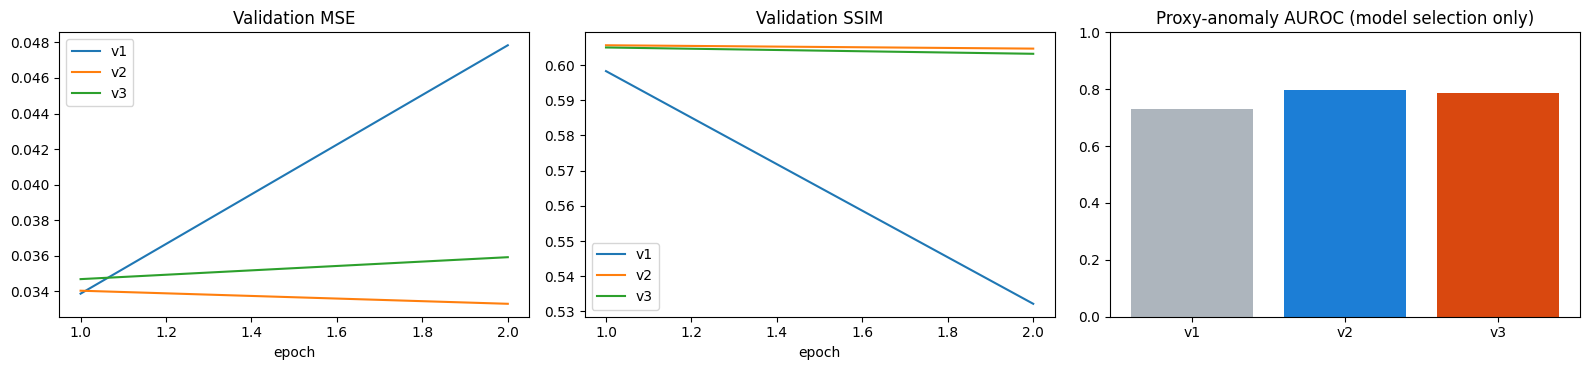

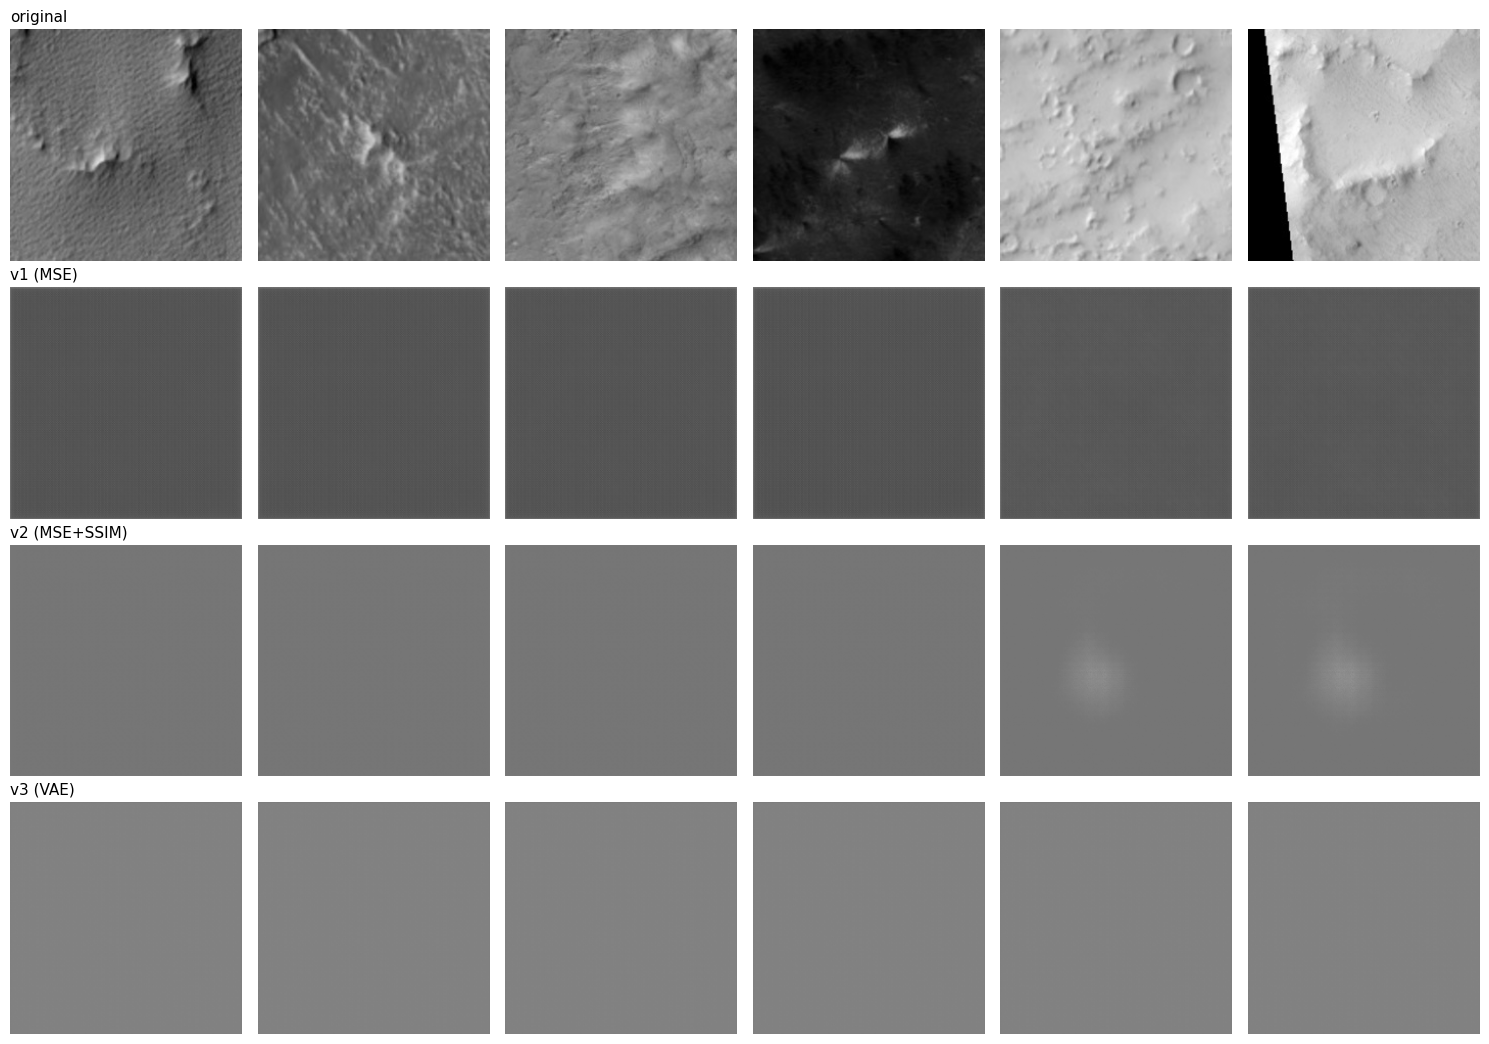

,val_mse,val_ssim,sharpness_ratio,participation_ratio,std_cv,proxy_auroc,proxy_ap,auroc_splice,auroc_domain,auroc_glitch
version,,,,,,,,,,
v1,0.0478,0.5322,1.0715,1.2254,0.5723,0.7302,0.8731,0.6905,0.8571,0.6429
v2,0.0333,0.6047,0.1281,1.0301,0.6225,0.7976,0.9025,0.6964,0.9524,0.7440
v3,0.0359,0.6032,0.1695,1.4325,0.5726,0.7857,0.9152,0.7381,0.9821,0.6369


In [22]:
# learning curves
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
for vname, hist in histories.items():
    ax[0].plot(hist["epoch"], hist["val_mse"], label=vname)
    ax[1].plot(hist["epoch"], hist["val_ssim"], label=vname)
ax[0].set_title("Validation MSE"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].set_title("Validation SSIM"); ax[1].set_xlabel("epoch"); ax[1].legend()
ax[2].bar(version_df.index, version_df["proxy_auroc"], color=["#adb5bd", "#1c7ed6", "#d9480f"])
ax[2].set_ylim(0.0, 1.0); ax[2].set_title("Proxy-anomaly AUROC (model selection only)")
plt.tight_layout(); plt.savefig(CHANGELOG_DIR / "curves.png", dpi=130); plt.show()

# same validation crops reconstructed by every version
cmp_idx = val_idx[:6]
fig, axes = plt.subplots(4, 6, figsize=(15, 10.5))
with torch.no_grad():
    xb = X[cmp_idx].float() / 255.0
    recs = {v: models[v].eval()(xb)[0] for v in models}
labels = ["original", "v1 (MSE)", "v2 (MSE+SSIM)", "v3 (VAE)"]
for col in range(6):
    imgs = [xb[col, 0], recs["v1"][col, 0], recs["v2"][col, 0], recs["v3"][col, 0]]
    for row in range(4):
        axes[row, col].imshow(imgs[row].cpu().numpy(), cmap="gray", vmin=0, vmax=1); axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(labels[row], loc="left", fontsize=11)
plt.tight_layout(); plt.savefig(CHANGELOG_DIR / "recon_compare.png", dpi=110); plt.show()
display(version_df.round(4))

In [23]:
vd = version_df
def better(new, old, higher_is_better=True, tol=1e-4):
    delta = new - old
    if abs(delta) <= tol:
        return "no measurable change"
    return "improved" if (delta > 0) == higher_is_better else "got worse"

weak_cls_v2 = vd.loc["v2", ["auroc_splice", "auroc_domain", "auroc_glitch"]].astype(float).idxmin().replace("auroc_", "")
sharp1 = vd.loc["v1", "sharpness_ratio"]

journal = f"""# Engineering Journal - NSSC 2026 Mars HiRISE Anomaly Detection
Latent size {LATENT_DIM} (chosen by the sweep in section 1.1), {EPOCHS} epochs per version, AdamW lr {LR}, batch {BATCH}, seed {SEED}.
Proxy-AUROC = separability of *synthetic* spliced / terrestrial / glitch images from held-out normal crops. It was used **only** to compare
iterations, never for training or for the final threshold.

## v1 - Baseline (CAE + MSE)
- **Setup:** 5-stage strided-conv encoder, linear bottleneck, mirrored transposed-conv decoder, plain MSE, raw latent -> Isolation Forest.
- **Result:** val MSE {vd.loc['v1','val_mse']:.5f}, val SSIM {vd.loc['v1','val_ssim']:.4f}, sharpness ratio {sharp1:.3f}, proxy AUROC {vd.loc['v1','proxy_auroc']:.3f}.

## v2 - Add an SSIM term to the loss
- **Symptom:** v1 reconstructions keep {sharp1:.0%} of the input's gradient energy (sharpness ratio {sharp1:.3f}; 1.0 = as sharp as the input) with val SSIM {vd.loc['v1','val_ssim']:.4f}. {'This confirms visible over-smoothing of craters, ridgelines and dune texture (see changelog/recon_compare.png).' if sharp1 < 0.95 else 'Blur is mild, so this change tests whether structure-aware training still helps.'}
- **Diagnosis:** MSE rewards the conditional-mean pixel value, so uncertain fine structure is averaged away; MSE also barely penalises misplaced edges.
- **Fix:** loss = {LAMBDA_MSE:g} x MSE + (1 - SSIM) with a custom Gaussian-window SSIM (MSE keeps absolute brightness, SSIM keeps local structure).
- **Outcome:** val SSIM {vd.loc['v1','val_ssim']:.4f} -> {vd.loc['v2','val_ssim']:.4f} ({better(vd.loc['v2','val_ssim'], vd.loc['v1','val_ssim'])}); sharpness ratio {sharp1:.3f} -> {vd.loc['v2','sharpness_ratio']:.3f} ({better(vd.loc['v2','sharpness_ratio'], sharp1)}); val MSE {vd.loc['v1','val_mse']:.5f} -> {vd.loc['v2','val_mse']:.5f} ({better(vd.loc['v2','val_mse'], vd.loc['v1','val_mse'], higher_is_better=False, tol=1e-6)}); proxy AUROC {vd.loc['v1','proxy_auroc']:.3f} -> {vd.loc['v2','proxy_auroc']:.3f} ({better(vd.loc['v2','proxy_auroc'], vd.loc['v1','proxy_auroc'], tol=1e-3)}).

## v3 - Regularised latent (VAE) and standardised latent for the Isolation Forest
- **Symptom:** in v2 the latent geometry is uneven: per-dimension scale CV {vd.loc['v2','std_cv']:.2f}, effective dimensionality {vd.loc['v2','participation_ratio']:.1f} of {LATENT_DIM}; the weakest proxy class is **{weak_cls_v2}** (AUROC {vd.loc['v2','auroc_'+weak_cls_v2]:.3f}).
- **Diagnosis:** an unregularised autoencoder places codes in an arbitrary geometry; the Isolation Forest splits on random axis-aligned cuts, so a few high-variance dimensions dominate isolation depth and the rest are wasted.
- **Fix:** variational bottleneck (KL weight {BETA_KL:g}, warm-up {KL_WARMUP} epochs) so the latent is pulled toward a common scale, plus per-dimension standardisation before the forest. The mean `mu` is the latent vector.
- **Outcome:** scale CV {vd.loc['v2','std_cv']:.2f} -> {vd.loc['v3','std_cv']:.2f}; effective dims {vd.loc['v2','participation_ratio']:.1f} -> {vd.loc['v3','participation_ratio']:.1f}; proxy AUROC {vd.loc['v2','proxy_auroc']:.3f} -> {vd.loc['v3','proxy_auroc']:.3f} ({better(vd.loc['v3','proxy_auroc'], vd.loc['v2','proxy_auroc'], tol=1e-3)}); val SSIM {vd.loc['v2','val_ssim']:.4f} -> {vd.loc['v3','val_ssim']:.4f} ({better(vd.loc['v3','val_ssim'], vd.loc['v2','val_ssim'])}).

## Final selection and thresholding
- **Selected version:** {FINAL} ({'highest proxy AUROC' if FINAL_VERSION == 'auto' else 'forced by configuration'}).
- **Threshold:** {THRESHOLD_METHOD} = {THRESHOLD:.5f} flags {n_flagged} of {N} crops ({100 * n_flagged / N:.2f}%). The score distribution has skewness {skew:.2f} and excess kurtosis {exkurt:.2f}, so mu + k sigma was not used as the primary rule; the robust modified z-score (median/MAD) was, with elbow and KDE-valley as cross-checks. Isolation Forest contamination = 'auto' (not used to fix the count).
- **Honest limits:** iterations need not improve every metric; the proxy set approximates, but does not equal, the hidden Genesis Outliers; the heatmap hypotheses in 3.2 are physical interpretations, not confirmed classes.
"""
(CHANGELOG_DIR / "ENGINEERING_JOURNAL.md").write_text(journal, encoding="utf-8")
display(Markdown(journal))

# Engineering Journal - NSSC 2026 Mars HiRISE Anomaly Detection
Latent size 64 (chosen by the sweep in section 1.1), 2 epochs per version, AdamW lr 0.001, batch 32, seed 42.
Proxy-AUROC = separability of *synthetic* spliced / terrestrial / glitch images from held-out normal crops. It was used **only** to compare
iterations, never for training or for the final threshold.

## v1 - Baseline (CAE + MSE)
- **Setup:** 5-stage strided-conv encoder, linear bottleneck, mirrored transposed-conv decoder, plain MSE, raw latent -> Isolation Forest.
- **Result:** val MSE 0.04784, val SSIM 0.5322, sharpness ratio 1.072, proxy AUROC 0.730.

## v2 - Add an SSIM term to the loss
- **Symptom:** v1 reconstructions keep 107% of the input's gradient energy (sharpness ratio 1.072; 1.0 = as sharp as the input) with val SSIM 0.5322. Blur is mild, so this change tests whether structure-aware training still helps.
- **Diagnosis:** MSE rewards the conditional-mean pixel value, so uncertain fine structure is averaged away; MSE also barely penalises misplaced edges.
- **Fix:** loss = 10 x MSE + (1 - SSIM) with a custom Gaussian-window SSIM (MSE keeps absolute brightness, SSIM keeps local structure).
- **Outcome:** val SSIM 0.5322 -> 0.6047 (improved); sharpness ratio 1.072 -> 0.128 (got worse); val MSE 0.04784 -> 0.03330 (improved); proxy AUROC 0.730 -> 0.798 (improved).

## v3 - Regularised latent (VAE) and standardised latent for the Isolation Forest
- **Symptom:** in v2 the latent geometry is uneven: per-dimension scale CV 0.62, effective dimensionality 1.0 of 64; the weakest proxy class is **splice** (AUROC 0.696).
- **Diagnosis:** an unregularised autoencoder places codes in an arbitrary geometry; the Isolation Forest splits on random axis-aligned cuts, so a few high-variance dimensions dominate isolation depth and the rest are wasted.
- **Fix:** variational bottleneck (KL weight 0.001, warm-up 1 epochs) so the latent is pulled toward a common scale, plus per-dimension standardisation before the forest. The mean `mu` is the latent vector.
- **Outcome:** scale CV 0.62 -> 0.57; effective dims 1.0 -> 1.4; proxy AUROC 0.798 -> 0.786 (got worse); val SSIM 0.6047 -> 0.6032 (got worse).

## Final selection and thresholding
- **Selected version:** v2 (highest proxy AUROC).
- **Threshold:** mad = 0.44965 flags 98 of 500 crops (19.60%). The score distribution has skewness 1.93 and excess kurtosis 2.97, so mu + k sigma was not used as the primary rule; the robust modified z-score (median/MAD) was, with elbow and KDE-valley as cross-checks. Isolation Forest contamination = 'auto' (not used to fix the count).
- **Honest limits:** iterations need not improve every metric; the proxy set approximates, but does not equal, the hidden Genesis Outliers; the heatmap hypotheses in 3.2 are physical interpretations, not confirmed classes.


### Save deliverables and inference artifacts
The trained model, the fitted Isolation Forest and the threshold are stored in `artifacts/` so the interactive tool below (and the Streamlit app) can reuse them without retraining.

In [24]:
torch.save({"state_dict": final_model.state_dict(), "latent_dim": LATENT_DIM, "variational": final_cfg["variational"],
            "base": BASE_CH, "version": FINAL}, OUT_DIR / "final_model.pth")
joblib.dump({"scaler": scaler_final, "iforest": iforest}, OUT_DIR / "iforest_mars.joblib")
(OUT_DIR / "threshold.json").write_text(json.dumps({"method": THRESHOLD_METHOD, "threshold": float(THRESHOLD), "version": FINAL,
                                                   "latent_dim": LATENT_DIM, "n_images": int(N), "n_flagged": n_flagged}, indent=2))
scored.sort_values("novelty", ascending=False).to_csv(OUT_DIR / "novelty_scores.csv", index=False)
np.save(OUT_DIR / "latents.npy", Z)
version_df.to_csv(OUT_DIR / "version_metrics.csv")
print("saved ->", sorted(p.name for p in OUT_DIR.iterdir()))

saved -> ['final_model.pth', 'iforest_mars.joblib', 'latents.npy', 'novelty_scores.csv', 'threshold.json', 'version_metrics.csv']


# Inference - Find the Most Different Images (clean UI)
**How to use:** drop *any* images (or a `.zip`) into the `input_images/` folder that sits next to this notebook, or use the upload button, then press **Find most different images**. Any number *n* of images works (n >= 3); sub-folders are scanned automatically.

**Output:** (1) the **top-5 most different images**, then (2) a **next tier** of images whose normalised novelty score lies within **10 %** of image #5 (adjustable).

**Two modes**
- **Any images (batch)** - fits a fresh Isolation Forest on *this batch only*: "which images stand out from the others here?". Features = the Mars-trained latent + simple handcrafted descriptors (colour, noise, clipping, banding, spectrum, edges), robustly standardised. Works for human photos, objects, anything.
- **Mars crops (trained model)** - scores the images against the model and the statistical threshold from Phase 2. Use only for HiRISE-like crops.

**Honest reading of the output:** the top 5 are always the *least typical* of the batch; the pill on each card says whether it is a *clear outlier* (modified z > 3.5) or only a *weak outlier*. The encoder was trained on Mars, so it can miss purely semantic differences (e.g. a different animal) that do not change texture, colour or structure.

In [25]:
%%writefile mars_backend_body.py
IMG = 227
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp", ".gif"}


# ----------------------------------------------------------------------------
# 1. FOLDER INGESTION  (any folder, any number of images, nested folders OK)
# ----------------------------------------------------------------------------
def collect_image_paths(folder):
    """Recursively find every image file under `folder` (sorted, hidden files skipped)."""
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")
    paths = []
    for p in sorted(folder.rglob("*")):
        if not p.is_file():
            continue
        if p.suffix.lower() not in IMAGE_EXTS:
            continue
        if any(part.startswith(".") or part == "__MACOSX" for part in p.parts):
            continue
        paths.append(p)
    return paths


def extract_zip_into(zip_source, dest):
    """Safely extract a .zip (path or bytes) into `dest`. Blocks path traversal."""
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    if isinstance(zip_source, (bytes, bytearray, memoryview)):
        zip_source = io.BytesIO(bytes(zip_source))
    with zipfile.ZipFile(zip_source) as zf:
        for member in zf.infolist():
            target = (dest / member.filename).resolve()
            if not str(target).startswith(str(dest.resolve())):
                continue  # path traversal attempt -> skip
            zf.extract(member, dest)
    return dest


def load_rgb(path):
    """Open any image as 8-bit RGB (EXIF-rotated). Returns None if unreadable."""
    try:
        with Image.open(path) as im:
            im = ImageOps.exif_transpose(im)
            if im.mode in ("I;16", "I", "F"):
                arr = np.asarray(im, dtype=np.float32)
                arr = (255.0 * (arr - arr.min()) / max(arr.max() - arr.min(), 1e-6)).astype(np.uint8)
                im = Image.fromarray(arr)
            return im.convert("RGB")
    except Exception:
        return None


def to_gray227(rgb):
    """Same preprocessing as training: grayscale, 227x227, float32 in [0, 1]."""
    g = rgb.convert("L").resize((IMG, IMG), Image.BILINEAR)
    return np.asarray(g, dtype=np.float32) / 255.0


# ----------------------------------------------------------------------------
# 2. HANDCRAFTED DESCRIPTORS  (no pretrained weights; pure numpy / PIL)
#    They complement the Mars-trained latent so that colour, noise, clipping,
#    banding and frequency-content differences are also detected.
# ----------------------------------------------------------------------------
_YY, _XX = np.mgrid[0:IMG, 0:IMG]
_RADIUS = np.sqrt((_YY - IMG // 2) ** 2 + (_XX - IMG // 2) ** 2)
_RAD_EDGES = np.linspace(0, IMG // 2, 9)


def handcrafted_features(gray, rgb_small):
    """gray: float32 (227,227) in [0,1]; rgb_small: PIL RGB 227x227. Returns 1-D float vector."""
    feats = []

    hist, _ = np.histogram(gray, bins=16, range=(0.0, 1.0))
    feats.extend((hist / hist.sum()).tolist())                       # 16 intensity-histogram bins

    feats.extend([gray.mean(), gray.std(),
                  np.percentile(gray, 5), np.percentile(gray, 95)])    # 4 global stats

    gx = np.abs(np.diff(gray, axis=1))
    gy = np.abs(np.diff(gray, axis=0))
    grad = np.concatenate([gx.ravel(), gy.ravel()])
    feats.extend([grad.mean(), grad.std(), float((grad > 0.1).mean())])  # 3 gradient / edge-density

    blur = (gray[:-2, :-2] + gray[:-2, 1:-1] + gray[:-2, 2:] +
            gray[1:-1, :-2] + gray[1:-1, 1:-1] + gray[1:-1, 2:] +
            gray[2:, :-2] + gray[2:, 1:-1] + gray[2:, 2:]) / 9.0
    feats.append(float((gray[1:-1, 1:-1] - blur).std()))               # 1 noise estimate

    power = np.abs(np.fft.fftshift(np.fft.fft2(gray - gray.mean()))) ** 2
    for b in range(8):
        mask = (_RADIUS >= _RAD_EDGES[b]) & (_RADIUS < _RAD_EDGES[b + 1])
        feats.append(float(np.log1p(power[mask].mean())))               # 8 radial spectrum bins

    feats.extend([float((gray <= 0.01).mean()), float((gray >= 0.99).mean())])  # 2 clipping fractions
    feats.extend([float(gray.mean(axis=1).std()), float(gray.mean(axis=0).std())])  # 2 row/col banding

    rgb = np.asarray(rgb_small, dtype=np.float32) / 255.0
    sat = np.asarray(rgb_small.convert("HSV"), dtype=np.float32)[..., 1] / 255.0
    feats.extend([float(sat.mean()), float(sat.std()),
                  float(np.abs(rgb[..., 0] - rgb[..., 1]).mean()),
                  float(np.abs(rgb[..., 1] - rgb[..., 2]).mean())])     # 4 colour statistics
    return np.asarray(feats, dtype=np.float32)


# ----------------------------------------------------------------------------
# 3. SCORING HELPERS
# ----------------------------------------------------------------------------
def robust_standardize(M):
    """Median / MAD scaling per column (outlier-resistant), clipped to +-10."""
    med = np.median(M, axis=0)
    mad = np.median(np.abs(M - med), axis=0) * 1.4826
    std = M.std(axis=0)
    scale = np.maximum(mad, 0.5 * std)
    scale[scale < 1e-8] = 1.0
    return np.clip((M - med) / scale, -10.0, 10.0)


def modified_z(scores):
    """Iglewicz-Hoaglin modified z-score (robust to the skew of IF scores)."""
    med = np.median(scores)
    mad = np.median(np.abs(scores - med))
    if mad < 1e-12:
        std = scores.std()
        return (scores - med) / (std if std > 1e-12 else 1.0)
    return 0.6745 * (scores - med) / mad


def error_overlay(gray, recon, alpha=0.5):
    """Jet heatmap of |original - reconstruction| blended over the image. Returns RGB uint8."""
    from scipy.ndimage import gaussian_filter
    import matplotlib
    err = gaussian_filter(np.abs(gray - recon), sigma=2.0)
    err = err / max(np.percentile(err, 99), 1e-6)
    err = np.clip(err, 0, 1)
    heat = matplotlib.colormaps["jet"](err)[..., :3]
    base = np.repeat(gray[..., None], 3, axis=2)
    return (255 * ((1 - alpha) * base + alpha * heat)).astype(np.uint8)


def _thumb(rgb, max_side=260):
    w, h = rgb.size
    s = max_side / max(w, h)
    if s < 1:
        rgb = rgb.resize((max(1, int(w * s)), max(1, int(h * s))), Image.LANCZOS)
    return np.asarray(rgb, dtype=np.uint8)


# ----------------------------------------------------------------------------
# 4. ENGINE  (backend used by the notebook UI and the Streamlit app)
# ----------------------------------------------------------------------------
class AnomalyEngine:
    def __init__(self, artifacts_dir="artifacts", device=None):
        self.artifacts_dir = Path(artifacts_dir)
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
        self.model = None
        self.mars_pipe = None
        self.mars_meta = None
        self._load_artifacts()

    def _load_artifacts(self):
        ckpt_path = self.artifacts_dir / "final_model.pth"
        if ckpt_path.exists():
            ckpt = torch.load(ckpt_path, map_location=self.device)
            self.model = ConvAE(latent_dim=ckpt["latent_dim"], variational=ckpt["variational"],
                                base=ckpt["base"]).to(self.device)
            self.model.load_state_dict(ckpt["state_dict"])
            self.model.eval()
        pipe_path = self.artifacts_dir / "iforest_mars.joblib"
        meta_path = self.artifacts_dir / "threshold.json"
        if pipe_path.exists() and meta_path.exists():
            self.mars_pipe = joblib.load(pipe_path)
            self.mars_meta = json.loads(meta_path.read_text())

    @property
    def has_model(self):
        return self.model is not None

    @torch.no_grad()
    def _encode_decode(self, grays, batch=32):
        latents, recons = [], []
        for i in range(0, len(grays), batch):
            xb = torch.from_numpy(np.stack(grays[i:i + batch])).unsqueeze(1).to(self.device)
            recon, mu, _ = self.model(xb)
            latents.append(mu.cpu().numpy())
            recons.append(recon.squeeze(1).cpu().numpy())
        return np.concatenate(latents), np.concatenate(recons)

    def run(self, folder, top_k=5, band=0.10, mode="batch", max_band=24, progress=None):
        """
        mode="batch": fit a fresh Isolation Forest on THIS batch only -> 'most different within the batch'.
        mode="mars" : score against the Mars-trained pipeline and the Phase-2 statistical threshold.
        band        : near-miss tier = images NOT in the top-k whose normalised score lies within
                      `band` (e.g. 0.10 = 10 percentage points) of the k-th image's normalised score.
        """
        def report(frac, text):
            if progress is not None:
                progress(frac, text)

        if mode == "mars" and (not self.has_model or self.mars_pipe is None):
            raise RuntimeError("Mars mode needs artifacts/ (final_model.pth, iforest_mars.joblib, "
                               "threshold.json). Run the training sections of the notebook first.")

        paths = collect_image_paths(folder)
        if len(paths) == 0:
            raise ValueError(f"No images found in '{folder}'. Supported: {sorted(IMAGE_EXTS)}")

        names, grays, rgbs_small, thumbs, hand = [], [], [], [], []
        failed = []
        for i, p in enumerate(paths):
            report(0.05 + 0.35 * i / len(paths), f"Reading images {i + 1}/{len(paths)}")
            rgb = load_rgb(p)
            if rgb is None:
                failed.append(str(p))
                continue
            gray = to_gray227(rgb)
            small = rgb.resize((IMG, IMG), Image.BILINEAR)
            names.append(str(p.relative_to(Path(folder))))
            grays.append(gray)
            rgbs_small.append(small)
            thumbs.append(_thumb(rgb))
            hand.append(handcrafted_features(gray, small))
        n = len(grays)
        if n < 3:
            raise ValueError(f"Need at least 3 readable images, found {n}.")
        top_k = int(min(top_k, n))

        latents, recons = None, None
        if self.has_model:
            report(0.45, "Encoding with the Mars-trained autoencoder")
            latents, recons = self._encode_decode(grays)

        report(0.7, "Scoring novelty")
        hand = np.stack(hand)
        hz = robust_standardize(hand) / np.sqrt(hand.shape[1])
        if mode == "mars":
            Z = latents
            if self.mars_pipe["scaler"] is not None:
                Z = self.mars_pipe["scaler"].transform(Z)
            scores = -self.mars_pipe["iforest"].score_samples(Z)
            threshold = float(self.mars_meta["threshold"])
            feat_space = None
        else:
            if latents is not None:
                zz = robust_standardize(latents) / np.sqrt(latents.shape[1])
                feat_space = np.hstack([zz, hz])
            else:
                feat_space = hz
            scores = np.zeros(n)
            n_seeds = 5
            for seed in range(n_seeds):
                forest = IsolationForest(n_estimators=300, max_samples=min(256, n),
                                         contamination="auto", random_state=seed)
                forest.fit(feat_space)
                scores += -forest.score_samples(feat_space)   # higher = more anomalous (competition convention)
            scores /= n_seeds
            threshold = None

        s_min, s_max = float(scores.min()), float(scores.max())
        norm = (scores - s_min) / max(s_max - s_min, 1e-12)
        zmod = modified_z(scores)
        order = np.argsort(-scores)

        second_opinion = None
        if feat_space is not None:
            center = np.median(feat_space, axis=0)
            dist = np.linalg.norm(feat_space - center, axis=1)
            from scipy.stats import spearmanr
            second_opinion = float(spearmanr(scores, dist)[0])

        kth_norm = norm[order[top_k - 1]]
        records = []
        for rank, idx in enumerate(order[:top_k], start=1):
            records.append(self._record(idx, rank, "top", names, scores, norm, zmod, thumbs,
                                        grays, recons, threshold))
        rank = top_k
        for idx in order[top_k:]:
            if norm[idx] >= kth_norm - band and (rank - top_k) < max_band:
                rank += 1
                records.append(self._record(idx, rank, "near", names, scores, norm, zmod, thumbs,
                                            grays, recons, threshold))
            else:
                break
        report(1.0, "Done")
        return {"records": records, "n_images": n, "failed": failed, "mode": mode,
                "used_model": self.has_model, "threshold": threshold, "band": band, "top_k": top_k,
                "all_names": names, "all_scores": scores.tolist(), "spearman_vs_distance": second_opinion}

    def _record(self, idx, rank, tier, names, scores, norm, zmod, thumbs, grays, recons, threshold):
        heat = None
        if recons is not None:
            heat = error_overlay(grays[idx], recons[idx])
        rec = {"rank": rank, "tier": tier, "name": names[idx], "score": float(scores[idx]),
               "score_norm": float(norm[idx]), "z": float(zmod[idx]),
               "stands_out": bool(zmod[idx] > 3.5), "original": thumbs[idx], "heatmap": heat}
        if threshold is not None:
            rec["flagged"] = bool(scores[idx] > threshold)
        return rec


# ----------------------------------------------------------------------------
# 5. GALLERY RENDERING (HTML for the notebook UI)
# ----------------------------------------------------------------------------
def _png_b64(arr):
    buf = io.BytesIO()
    Image.fromarray(arr).save(buf, format="JPEG", quality=88)
    return base64.b64encode(buf.getvalue()).decode("ascii")


_CSS = """
<style>
.mz-wrap{font-family:system-ui,-apple-system,Segoe UI,Roboto,sans-serif;max-width:1100px}
.mz-h{margin:18px 0 4px;font-size:18px;font-weight:650}
.mz-sub{opacity:.7;font-size:13px;margin-bottom:10px}
.mz-grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(230px,1fr));gap:14px}
.mz-card{border:1px solid rgba(128,128,128,.35);border-radius:12px;padding:10px;position:relative}
.mz-card img{width:100%;border-radius:8px;display:block;margin-bottom:6px}
.mz-badge{position:absolute;top:8px;left:8px;background:#d9480f;color:#fff;font-weight:700;
 border-radius:999px;padding:2px 10px;font-size:12px;z-index:2}
.mz-badge.near{background:#6c757d}
.mz-name{font-size:12px;opacity:.75;word-break:break-all;margin-top:2px}
.mz-meta{font-size:13px;margin-top:4px}
.mz-pill{display:inline-block;font-size:11px;border-radius:6px;padding:1px 7px;margin-left:4px;
 border:1px solid rgba(128,128,128,.5)}
.mz-bar{height:6px;border-radius:3px;background:rgba(128,128,128,.25);margin-top:6px}
.mz-bar>div{height:6px;border-radius:3px;background:#d9480f}
.mz-lab{font-size:11px;opacity:.6;margin:2px 0}
</style>
"""


def _card_html(rec, with_heat):
    badge_cls = "mz-badge" if rec["tier"] == "top" else "mz-badge near"
    html = [f'<div class="mz-card"><span class="{badge_cls}">#{rec["rank"]}</span>']
    html.append(f'<div class="mz-lab">Original</div><img src="data:image/jpeg;base64,{_png_b64(rec["original"])}"/>')
    if with_heat and rec["heatmap"] is not None:
        html.append(f'<div class="mz-lab">Reconstruction-error heatmap</div>'
                    f'<img src="data:image/jpeg;base64,{_png_b64(rec["heatmap"])}"/>')
    pills = ""
    if "flagged" in rec:
        pills += f'<span class="mz-pill">{"above threshold" if rec["flagged"] else "below threshold"}</span>'
    else:
        pills += f'<span class="mz-pill">{"clear outlier" if rec["stands_out"] else "weak outlier"}</span>'
    html.append(f'<div class="mz-meta">score {rec["score"]:.3f} &middot; z {rec["z"]:.1f}{pills}</div>')
    html.append(f'<div class="mz-bar"><div style="width:{100 * rec["score_norm"]:.0f}%"></div></div>')
    html.append(f'<div class="mz-name">{rec["name"]}</div></div>')
    return "".join(html)


def render_gallery_html(result):
    top = [r for r in result["records"] if r["tier"] == "top"]
    near = [r for r in result["records"] if r["tier"] == "near"]
    parts = [_CSS, '<div class="mz-wrap">']
    mode_txt = ("scored against the Mars-trained model + statistical threshold"
                if result["mode"] == "mars" else "most different within this batch")
    parts.append(f'<div class="mz-sub">{result["n_images"]} images analysed &middot; {mode_txt}'
                 + ("" if result["used_model"] else " &middot; (no trained model found: handcrafted features only)")
                 + "</div>")
    parts.append(f'<div class="mz-h">Top {len(top)} most different images</div>')
    parts.append('<div class="mz-grid">' + "".join(_card_html(r, True) for r in top) + "</div>")
    pct = int(round(100 * result["band"]))
    parts.append(f'<div class="mz-h">Next tier: within {pct}% of the #{len(top)} image</div>')
    if near:
        parts.append(f'<div class="mz-sub">{len(near)} close-call image(s) whose normalised score is at most '
                     f'{pct} points below image #{len(top)}.</div>')
        parts.append('<div class="mz-grid">' + "".join(_card_html(r, False) for r in near) + "</div>")
    else:
        parts.append(f'<div class="mz-sub">No other image is within {pct}% of the #{len(top)} image: '
                     'the top group is clearly separated.</div>')
    if result["failed"]:
        parts.append(f'<div class="mz-sub">Skipped {len(result["failed"])} unreadable file(s).</div>')
    parts.append("</div>")
    return "".join(parts)

Overwriting mars_backend_body.py


In [26]:
# Compose the backend module: model_def.py (the SAME ConvAE used for training) + the engine code above
import importlib
BACKEND_HEADER = """import os, io, json, base64, zipfile
from pathlib import Path
import numpy as np
from PIL import Image, ImageOps
import torch, torch.nn as nn, torch.nn.functional as F
import joblib
from sklearn.ensemble import IsolationForest

IMG = 227

"""
Path("mars_backend.py").write_text(Path("model_def.py").read_text() + "\n\n" + BACKEND_HEADER + Path("mars_backend_body.py").read_text())
import mars_backend
importlib.reload(mars_backend)
engine = mars_backend.AnomalyEngine(OUT_DIR)
print("backend ready | trained model loaded:", engine.has_model, "| Mars-mode available:", engine.mars_pipe is not None)

backend ready | trained model loaded: True | Mars-mode available: True


In [27]:
%%writefile app.py
# Streamlit front end (optional): run with   streamlit run app.py
import tempfile, io
from pathlib import Path
import streamlit as st
import mars_backend as mb

st.set_page_config(page_title="Most different images", layout="wide")
st.title("Find the most different images")
st.caption("Drop any folder of images (or a .zip). The tool returns the top-K most different images, then the near-miss tier.")

@st.cache_resource
def get_engine():
    return mb.AnomalyEngine("artifacts")

engine = get_engine()
with st.sidebar:
    mode = st.radio("Mode", ["batch", "mars"], format_func=lambda m: "Any images (batch)" if m == "batch" else "Mars crops (trained model)")
    top_k = st.slider("Top-K", 1, 20, 5)
    band = st.slider("Near-miss band", 0.0, 0.5, 0.10, 0.01, format="%.2f")
    folder = st.text_input("Folder path (optional)", "input_images")
    uploads = st.file_uploader("...or upload images / a .zip", accept_multiple_files=True)
    st.write("Trained model loaded:", engine.has_model)

if st.button("Find most different images", type="primary"):
    work = Path(tempfile.mkdtemp())
    src = Path(folder) if folder and Path(folder).exists() and not uploads else work
    for up in uploads or []:
        if up.name.lower().endswith(".zip"):
            mb.extract_zip_into(up.getvalue(), work)
        else:
            (work / up.name).write_bytes(up.getvalue())
    bar = st.progress(0.0)
    try:
        res = engine.run(src, top_k=top_k, band=band, mode=mode, progress=lambda f, t: bar.progress(min(1.0, f), text=t))
    except Exception as exc:
        st.error(str(exc))
        st.stop()
    top = [r for r in res["records"] if r["tier"] == "top"]
    near = [r for r in res["records"] if r["tier"] == "near"]
    st.subheader(f"Top {len(top)} most different (of {res['n_images']} images)")
    cols = st.columns(min(5, len(top)))
    for i, rec in enumerate(top):
        with cols[i % len(cols)]:
            st.image(rec["original"], caption=f"#{rec['rank']}  score {rec['score']:.3f}  z {rec['z']:.1f}")
            if rec["heatmap"] is not None:
                st.image(rec["heatmap"], caption="reconstruction-error heatmap")
            st.caption(rec["name"])
    st.subheader(f"Next tier: within {int(round(band * 100))}% of #{len(top)}")
    if near:
        cols = st.columns(5)
        for i, rec in enumerate(near):
            with cols[i % 5]:
                st.image(rec["original"], caption=f"#{rec['rank']}  score {rec['score']:.3f}")
                st.caption(rec["name"])
    else:
        st.info("No other image is that close - the top group is clearly separated.")

Overwriting app.py


In [28]:
# ------------------------------ CLEAN UI (ipywidgets) ------------------------------
import ipywidgets as W
from IPython.display import display, HTML, clear_output

INPUT_DIR = Path("input_images"); INPUT_DIR.mkdir(exist_ok=True)

title = W.HTML("<div style='font-family:system-ui;'><div style='font-size:22px;font-weight:700'>Find the most different images</div>"
               "<div style='opacity:.7;font-size:13px'>Folder of any n images in &rarr; top-K most different + near-miss tier out</div></div>")
folder_box = W.Text(value=str(INPUT_DIR), description="Folder", style={"description_width": "55px"}, layout=W.Layout(width="440px"))
upload = W.FileUpload(accept=".zip,.jpg,.jpeg,.png,.bmp,.tif,.tiff,.webp,.gif", multiple=True, description="Upload images / .zip",
                      layout=W.Layout(width="190px"))
mode_tg = W.ToggleButtons(options=[("Any images (batch)", "batch"), ("Mars crops (trained model)", "mars")], value="batch")
topk_sl = W.IntSlider(value=5, min=1, max=20, description="Top-K", style={"description_width": "55px"}, layout=W.Layout(width="300px"))
band_sl = W.FloatSlider(value=0.10, min=0.0, max=0.5, step=0.01, readout_format=".0%", description="Near-miss band",
                        style={"description_width": "95px"}, layout=W.Layout(width="380px"))
run_btn = W.Button(description="Find most different images", button_style="primary", icon="search",
                   layout=W.Layout(width="280px", height="40px"))
progress = W.FloatProgress(value=0, min=0, max=1, layout=W.Layout(width="640px", visibility="hidden"))
status = W.HTML("")
results_out = W.Output()

def _uploaded_items(value):
    if isinstance(value, dict):                       # ipywidgets 7
        for name, meta in value.items():
            yield name, bytes(meta["content"])
    else:                                             # ipywidgets 8
        for item in value:
            yield item["name"], bytes(item["content"])

def _on_run(_):
    folder = Path(folder_box.value.strip() or "input_images")
    folder.mkdir(parents=True, exist_ok=True)
    with results_out:
        clear_output()
    n_saved = 0
    for name, content in _uploaded_items(upload.value):
        if name.lower().endswith(".zip"):
            mars_backend.extract_zip_into(content, folder)
        else:
            (folder / Path(name).name).write_bytes(content)
        n_saved += 1
    if n_saved:
        try:
            upload.value = ()
        except Exception:
            try:
                upload.value = {}
            except Exception:
                pass
    run_btn.disabled = True
    progress.layout.visibility = "visible"
    status.value = ""
    def cb(frac, text):
        progress.value = frac
        status.value = f"<span style='opacity:.7;font-size:13px'>{text}</span>"
    try:
        res = engine.run(folder, top_k=topk_sl.value, band=band_sl.value, mode=mode_tg.value, progress=cb)
    except Exception as exc:
        status.value = f"<span style='color:#c92a2a'>{exc}</span>"
        run_btn.disabled = False
        progress.layout.visibility = "hidden"
        return
    pd.DataFrame({"image": res["all_names"], "novelty_score": res["all_scores"]}) \
        .sort_values("novelty_score", ascending=False).to_csv("last_run_ranking.csv", index=False)
    with results_out:
        clear_output()
        display(HTML(mars_backend.render_gallery_html(res)))
    status.value = "<span style='opacity:.7;font-size:13px'>full ranking saved to last_run_ranking.csv</span>"
    run_btn.disabled = False
    progress.layout.visibility = "hidden"

run_btn.on_click(_on_run)
display(W.VBox([title, W.HBox([folder_box, upload]), mode_tg, W.HBox([topk_sl, band_sl]), run_btn, progress, status, results_out],
               layout=W.Layout(padding="10px", border="1px solid rgba(128,128,128,.35)", border_radius="12px", width="fit-content")))

### Programmatic use (same backend, no UI)
```python
res = engine.run("input_images", top_k=5, band=0.10, mode="batch")
[(r["rank"], r["tier"], r["name"], round(r["score"], 3)) for r in res["records"]]
```
Optional dashboard: `streamlit run app.py` (uses the same `mars_backend.py` and `artifacts/`).